# Held-out Fold -1 Ensemble Inference Visualization

Runs the five SegResNet CV fold checkpoints on only the left-out patients marked `fold == -1` in `data/cv_splits_qc.csv`. The notebook exports the same Slicer-ready per-patient files used by `inference_visualization.ipynb`, but with one ensemble prediction per patient and largest-connected-component postprocessing applied to the final binary prediction mask.

## Output layout

For each processed patient, this notebook writes:

- `volume_CT_LATE.nii.gz`
- `ground_truth_mask.nii.gz`
- `segmentation_ensemble_raw.nii.gz`
- `segmentation_ensemble_postprocessed.nii.gz`
- `segmentation_ensemble.nii.gz` as a compatibility copy of the postprocessed mask
- `metrics.csv`
- `slices_z_percentages_comparison.png`
- `three_plane_comparison.png`

It also writes cohort-level summary CSVs and `patient_output_folders.csv` files. The figures compare the low-quality/manual reference mask against both the raw ensemble prediction and the LCC-postprocessed ensemble prediction.

In [31]:
# Uncomment when running in a fresh environment.
# %pip install azure-ai-ml azure-identity azure-storage-blob nibabel monai omegaconf scipy matplotlib pandas

## 1. Configuration

`ASSET_ACCESS_MODE = "download"` resolves Azure ML data assets through the Azure ML SDK and downloads files from the backing datastore with `azure-storage-blob`. This avoids FUSE and works on macOS/local notebooks where `/dev/fuse` is unavailable.

Set `ASSET_ACCESS_MODE = "local"` if you already have the input data and model output folders locally, then edit `DATA_ROOT` and `FOLD_MODEL_ROOTS`.

In [32]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

SUBSCRIPTION_ID = "ab211f7b-463f-4833-9605-d260e596a35a"
RESOURCE_GROUP = "73da10b4-5dff-54e2-db0d-3a1fab882485"
WORKSPACE_NAME = "73da10b45dff54e2db0d3a1fab882485"
TENANT_ID = "ebbb4fc3-587b-477c-a1e8-ee47d8c02546"
AZURE_AUTH_MODE = "default"  # set to "browser" if DefaultAzureCredential cannot authenticate

INPUT_DATA_ASSET = "azureml:LEMS-CT-NIfTI:1"
PRECOMPUTED_ENSEMBLE_OUTPUT_ASSET = "azureml_f2b9e50f-cd95-4734-a354-cd9a8441536e_output_data_output_model:1"
FOLD_MODEL_ASSETS = {
    0: "azureml:azureml_d5e2bad6-4f29-41be-b98e-62c8b9021ac3_output_data_output_model:1",
    1: "azureml:azureml_58561397-f1a0-49b3-8d0a-cc9ba6b825c8_output_data_output_model:1",
    2: "azureml:azureml_f9fe6982-9c3c-4db6-aaf2-3542ddddfc79_output_data_output_model:1",
    3: "azureml:azureml_0542086e-7b08-467b-aeca-52df71ea30a9_output_data_output_model:1",
    4: "azureml:azureml_f2b9e50f-cd95-4734-a354-cd9a8441536e_output_data_output_model:1",
}

SPLIT_CSV = PROJECT_ROOT / "data" / "cv_splits_qc.csv"
QC_RESULTS_CSV = PROJECT_ROOT / "data" / "qc_results.csv"
CONFIG_PATH = PROJECT_ROOT / "config" / "train_config.yaml"
TEST_FOLD = -1
LOW_QUALITY_QC_VALUES = {"0", "1"}

LOCAL_ASSET_ROOT = PROJECT_ROOT / "notebooks" / "azure_assets" / "leftout_ensemble"
LOCAL_OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "leftout_fold_minus1_ensemble"
LOW_QUALITY_OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "output" / "QC_1_0_ensemble"
LOCAL_ASSET_ROOT.mkdir(parents=True, exist_ok=True)
LOCAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOW_QUALITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Use local assets present under notebooks/nifti_data/ instead of downloading from Azure ML
ASSET_ACCESS_MODE = "local"  # "download" or "local". No FUSE mount is used.
OVERWRITE_ASSET_DOWNLOADS = False

# When ASSET_ACCESS_MODE is "local", point DATA_ROOT to your local NIfTI folder.
DATA_ROOT = PROJECT_ROOT / "notebooks" / "nifti_data"
# User-provided local fold model roots (contains .pth checkpoints)
FOLD_MODEL_ROOTS = {
    0: PROJECT_ROOT / "notebooks" / "full_CV_segresnet_LCC" / "fold_0",
    1: PROJECT_ROOT / "notebooks" / "full_CV_segresnet_LCC" / "fold_1",
    2: PROJECT_ROOT / "notebooks" / "full_CV_segresnet_LCC" / "fold_2",
    3: PROJECT_ROOT / "notebooks" / "full_CV_segresnet_LCC" / "fold_3",
    4: PROJECT_ROOT / "notebooks" / "full_CV_segresnet_LCC" / "fold_4",
}

CASE_NAMES = None       # Example: ["TAVI_002", "TAVI_006"]. None = all fold -1 patients.
MAX_PATIENTS = None     # Example: 3 for a quick smoke run.
LOW_QUALITY_CASE_NAMES = None
LOW_QUALITY_MAX_PATIENTS = None
DISPLAY_FIRST_N_PATIENTS = 2

USE_EMA_WEIGHTS = False  # False matches scripts/inference_job.py. Set True to use EMA state if present.
NUM_WORKERS = 0
SLICE_PERCENTAGES = [13, 16, 19, 22, 25, 27, 29, 31, 34, 37, 40, 43, 47, 50, 53, 56, 59, 62, 65, 68, 71, 74, 77, 80]

print(f"Project root: {PROJECT_ROOT}")
print(f"Left-out output directory: {LOCAL_OUTPUT_DIR}")
print(f"QC 0/1 output directory: {LOW_QUALITY_OUTPUT_DIR}")
print(f"DATA_ROOT set to: {DATA_ROOT}")

Project root: /Users/ricca/Desktop/Health_Informatics_Internship_2026
Left-out output directory: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble
QC 0/1 output directory: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble
DATA_ROOT set to: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/nifti_data


## 2. Download or locate Azure ML assets

In [33]:
import re
import shutil
import sys
from pathlib import Path, PurePosixPath
from urllib.parse import unquote


def normalize_azureml_asset_uri(uri):
    uri = str(uri).strip()
    if uri.startswith("azureml:"):
        return uri
    if re.match(r"^azureml_[^:]+:\d+$", uri):
        return "azureml:" + uri
    raise ValueError(f"Expected an Azure ML asset URI like azureml:<name>:<version>, received: {uri}")


def parse_azureml_asset_uri(uri):
    normalized = normalize_azureml_asset_uri(uri)
    name_version = normalized.removeprefix("azureml:")
    name, version = name_version.rsplit(":", 1)
    return name, version


def get_credential():
    from azure.identity import DefaultAzureCredential, InteractiveBrowserCredential

    if AZURE_AUTH_MODE == "browser":
        return InteractiveBrowserCredential(tenant_id=TENANT_ID)
    return DefaultAzureCredential()


def get_ml_client(credential=None):
    from azure.ai.ml import MLClient

    credential = credential or get_credential()
    return MLClient(
        credential=credential,
        subscription_id=SUBSCRIPTION_ID,
        resource_group_name=RESOURCE_GROUP,
        workspace_name=WORKSPACE_NAME,
    )


def _directory_has_files(path):
    path = Path(path)
    return path.exists() and any(child.is_file() for child in path.rglob("*"))


def _find_patient_dir(root, patient_id):
    root = Path(root)
    direct = root / patient_id
    if direct.is_dir():
        return direct
    for match in root.rglob(patient_id):
        if match.is_dir():
            return match
    return None


def _asset_cache_ready(target_dir, patient_ids=None):
    target_dir = Path(target_dir)
    if not target_dir.exists():
        return False
    if patient_ids:
        return all(_find_patient_dir(target_dir, patient_id) is not None for patient_id in patient_ids)
    return _directory_has_files(target_dir)


def leftout_patient_ids_for_download():
    split_df = pd.read_csv(SPLIT_CSV)
    names = split_df[split_df["fold"].astype(int) == int(TEST_FOLD)]["patient_id"].astype(str).tolist()
    if CASE_NAMES:
        names = [name for name in names if name in set(CASE_NAMES)]
    if MAX_PATIENTS is not None:
        names = names[: int(MAX_PATIENTS)]
    return names


def low_quality_patient_ids_for_download():
    qc_df = pd.read_csv(QC_RESULTS_CSV)
    result_text = qc_df["QC RESULT"].astype(str).str.strip()
    rows = qc_df[result_text.isin(LOW_QUALITY_QC_VALUES)]
    names = rows["PATIENT"].astype(str).str.strip().tolist()
    if LOW_QUALITY_CASE_NAMES:
        names = [name for name in names if name in set(LOW_QUALITY_CASE_NAMES)]
    if LOW_QUALITY_MAX_PATIENTS is not None:
        names = names[: int(LOW_QUALITY_MAX_PATIENTS)]
    return names


def patient_ids_for_input_download():
    names = sorted(set(leftout_patient_ids_for_download()) | set(low_quality_patient_ids_for_download()))
    if not names:
        raise ValueError("No patient ids selected for input data download.")
    return names


def parse_azureml_datastore_uri(uri):
    uri = str(uri)
    match = re.search(r"/datastores/([^/]+)/paths/(.*)$", uri, flags=re.IGNORECASE)
    if not match:
        raise ValueError(
            "Only Azure ML datastore-backed assets can be downloaded without FUSE. "
            f"Asset path was: {uri}"
        )
    datastore_name = unquote(match.group(1))
    path_prefix = unquote(match.group(2)).strip("/")
    return datastore_name, path_prefix


def datastore_blob_location(datastore):
    account_name = getattr(datastore, "account_name", None)
    container_name = getattr(datastore, "container_name", None)

    if account_name and container_name:
        return account_name, container_name

    datastore_dict = datastore._to_dict() if hasattr(datastore, "_to_dict") else {}
    account_name = account_name or datastore_dict.get("account_name") or datastore_dict.get("accountName")
    container_name = container_name or datastore_dict.get("container_name") or datastore_dict.get("containerName")
    if account_name and container_name:
        return account_name, container_name

    raise ValueError(
        f"Datastore {getattr(datastore, 'name', '<unknown>')} does not expose an Azure Blob account/container."
    )


def blob_relative_path(blob_name, prefix):
    prefix = prefix.strip("/")
    if prefix and blob_name.startswith(prefix + "/"):
        return blob_name[len(prefix) + 1:]
    if blob_name == prefix:
        return ""
    return blob_name


def blob_matches_patients(relative_blob_path, patient_ids):
    if not patient_ids:
        return True
    parts = set(PurePosixPath(relative_blob_path).parts)
    return bool(parts & set(patient_ids))


def download_datastore_prefix(asset_path, target_dir, ml_client, credential, patient_ids=None):
    from azure.storage.blob import ContainerClient

    datastore_name, prefix = parse_azureml_datastore_uri(asset_path)
    datastore = ml_client.datastores.get(datastore_name)
    account_name, container_name = datastore_blob_location(datastore)
    container_client = ContainerClient(
        account_url=f"https://{account_name}.blob.core.windows.net",
        container_name=container_name,
        credential=credential,
    )

    target_dir = Path(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)
    prefix_for_listing = prefix + "/" if prefix else ""
    downloaded = 0
    skipped = 0
    for blob in container_client.list_blobs(name_starts_with=prefix_for_listing):
        relative = blob_relative_path(blob.name, prefix)
        if not relative or relative.endswith("/"):
            continue
        if not blob_matches_patients(relative, patient_ids):
            skipped += 1
            continue

        destination = target_dir / Path(*PurePosixPath(relative).parts)
        destination.parent.mkdir(parents=True, exist_ok=True)
        if destination.exists() and destination.stat().st_size == blob.size:
            skipped += 1
            continue

        with destination.open("wb") as file_obj:
            stream = container_client.download_blob(blob.name)
            file_obj.write(stream.readall())
        downloaded += 1

    print(f"Downloaded {downloaded} blob(s), skipped {skipped} existing/unselected blob(s): {target_dir}")
    return target_dir


def download_data_asset(asset_uri, target_dir, ml_client, credential, overwrite=False, patient_ids=None):
    target_dir = Path(target_dir)
    if overwrite and target_dir.exists():
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)

    if _asset_cache_ready(target_dir, patient_ids=patient_ids):
        print(f"Using existing local asset cache: {target_dir}")
        return target_dir

    name, version = parse_azureml_asset_uri(asset_uri)
    asset = ml_client.data.get(name=name, version=version)
    print(f"Resolving {name}:{version}")
    print(f"  asset path: {asset.path}")
    if patient_ids:
        print(f"  downloading only {len(patient_ids)} selected patient folder(s)")
    return download_datastore_prefix(asset.path, target_dir, ml_client, credential, patient_ids=patient_ids)


if ASSET_ACCESS_MODE == "download":
    import pandas as pd

    credential = get_credential()
    ml_client = get_ml_client(credential)
    input_patient_ids = patient_ids_for_input_download()
    DATA_ROOT = download_data_asset(
        INPUT_DATA_ASSET,
        LOCAL_ASSET_ROOT / "input_data",
        ml_client,
        credential,
        OVERWRITE_ASSET_DOWNLOADS,
        patient_ids=input_patient_ids,
    )
    FOLD_MODEL_ROOTS = {
        fold: download_data_asset(
            uri,
            LOCAL_ASSET_ROOT / f"fold_{fold}_model",
            ml_client,
            credential,
            OVERWRITE_ASSET_DOWNLOADS,
        )
        for fold, uri in FOLD_MODEL_ASSETS.items()
    }
elif ASSET_ACCESS_MODE == "local":
    print("ASSET_ACCESS_MODE is local; using DATA_ROOT and FOLD_MODEL_ROOTS as configured above.")
else:
    raise ValueError("ASSET_ACCESS_MODE must be 'download' or 'local'.")

print(f"DATA_ROOT: {DATA_ROOT}")
for fold, root in FOLD_MODEL_ROOTS.items():
    print(f"fold {fold}: {root}")

ASSET_ACCESS_MODE is local; using DATA_ROOT and FOLD_MODEL_ROOTS as configured above.
DATA_ROOT: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/nifti_data
fold 0: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/full_CV_segresnet_LCC/fold_0
fold 1: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/full_CV_segresnet_LCC/fold_1
fold 2: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/full_CV_segresnet_LCC/fold_2
fold 3: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/full_CV_segresnet_LCC/fold_3
fold 4: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/full_CV_segresnet_LCC/fold_4


## 3. Imports and runtime setup

In [34]:
import inspect
from contextlib import nullcontext

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import nibabel as nib
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from monai.data import DataLoader, Dataset, MetaTensor, decollate_batch
from monai.inferers import sliding_window_inference
from monai.transforms import (
    AsDiscreted,
    Compose,
    CropForegroundd,
    EnsureChannelFirstd,
    Invertd,
    LoadImaged,
    Orientationd,
    ScaleIntensityRanged,
    Spacingd,
)
from omegaconf import OmegaConf

try:
    from scipy.ndimage import binary_erosion, generate_binary_structure
    from scipy.spatial import cKDTree
except ImportError:
    binary_erosion = None
    generate_binary_structure = None
    cKDTree = None

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from lems_ct.src.models.model import get_segresnet
from lems_ct.src.utils.data import resolve_data_root
from scripts.lcc_postprocessing import discretize_clean_ensemble_probs, keep_largest_cc_numpy

cfg = OmegaConf.load(CONFIG_PATH)
TARGET_SPACING = tuple(float(v) for v in cfg.transforms.get("target_spacing", [1.0, 1.0, 1.0]))
ROI_SIZE = tuple(int(v) for v in cfg.transforms.get("roi_size", [96, 96, 96]))
SW_BATCH_SIZE = int(cfg.inference.get("sw_batch_size", 4))
OVERLAP = float(cfg.inference.get("overlap", 0.5))
SW_MODE = str(cfg.inference.get("mode", "gaussian"))
OUT_CHANNELS = int(cfg.model.get("out_channels", 2))

if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


def autocast_context():
    if device.type == "cuda":
        return torch.amp.autocast("cuda")
    if device.type == "mps":
        return torch.amp.autocast("mps")
    return nullcontext()


def release_device_cache():
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps" and hasattr(torch, "mps"):
        torch.mps.empty_cache()


print(f"Device: {device}")
print(f"ROI: {ROI_SIZE} | spacing: {TARGET_SPACING} | SW batch: {SW_BATCH_SIZE} | overlap: {OVERLAP} | mode: {SW_MODE}")

Device: mps
ROI: (96, 96, 96) | spacing: (1.0, 1.0, 1.0) | SW batch: 4 | overlap: 0.5 | mode: gaussian


## 4. Select only left-out patients (`fold == -1`)

In [35]:
def leftout_patient_ids(split_csv=SPLIT_CSV, test_fold=TEST_FOLD):
    split_df = pd.read_csv(split_csv)
    rows = split_df[split_df["fold"].astype(int) == int(test_fold)]
    return rows["patient_id"].astype(str).tolist()


def qc_low_quality_patient_ids(qc_csv=QC_RESULTS_CSV, qc_values=LOW_QUALITY_QC_VALUES):
    qc_df = pd.read_csv(qc_csv)
    result_text = qc_df["QC RESULT"].astype(str).str.strip()
    rows = qc_df[result_text.isin({str(value) for value in qc_values})]
    return rows["PATIENT"].astype(str).str.strip().tolist()


def locate_patient_root(data_root, patient_ids):
    data_root = Path(resolve_data_root(data_root))
    candidates = [
        data_root,
        data_root / "DATA_REGISTERED_FIXED_LATE",
        data_root / "NIFTI" / "DATA_REGISTERED_FIXED_LATE",
    ]
    for candidate in candidates:
        if all((candidate / patient_id).exists() for patient_id in patient_ids[: min(3, len(patient_ids))]):
            return candidate

    for patient_id in patient_ids[: min(5, len(patient_ids))]:
        matches = [path for path in data_root.rglob(patient_id) if path.is_dir()]
        for match in matches:
            if (match / "CT_LATE.nii.gz").exists():
                return match.parent

    raise FileNotFoundError(
        f"Could not locate patient folders under {data_root}. Checked for: {patient_ids[:5]}"
    )


def validate_nifti_file(path):
    path = Path(path)
    try:
        image = nib.load(str(path))
        _ = image.shape
    except Exception as exc:
        return False, f"{type(exc).__name__}: {exc}"
    return True, ""


def validate_case_files(image_path, label_path):
    image_ok, image_reason = validate_nifti_file(image_path)
    if not image_ok:
        return False, f"CT_LATE unreadable: {image_reason}"

    label_ok, label_reason = validate_nifti_file(label_path)
    if not label_ok:
        return False, f"registration_mask unreadable: {label_reason}"

    image_shape = nib.load(str(image_path)).shape
    label_shape = nib.load(str(label_path)).shape
    if tuple(image_shape) != tuple(label_shape):
        return False, f"image/label shape mismatch: image={image_shape}, label={label_shape}"

    return True, ""


def select_cases_by_patient_ids(data_root, patient_ids, case_names=None, max_patients=None, cohort_label="cases"):
    selected_names = list(case_names) if case_names else list(patient_ids)
    data_root = locate_patient_root(data_root, selected_names)

    cases = []
    missing = []
    unreadable = []
    for patient_id in selected_names:
        image_path = data_root / patient_id / "CT_LATE.nii.gz"
        label_path = data_root / patient_id / "registration_mask.nii.gz"
        if not image_path.exists() or not label_path.exists():
            missing.append(patient_id)
            continue

        is_valid, reason = validate_case_files(image_path, label_path)
        if is_valid:
            cases.append({"image": str(image_path), "label": str(label_path), "name": patient_id})
        else:
            unreadable.append({"patient_id": patient_id, "reason": reason, "image": str(image_path), "label": str(label_path)})

    if max_patients is not None:
        cases = cases[: int(max_patients)]

    if missing:
        print(f"Skipping {len(missing)} {cohort_label} patients missing image/label files. First missing: {missing[:10]}")
    if unreadable:
        print(f"Skipping {len(unreadable)} {cohort_label} patients with unreadable NIfTI files:")
        for item in unreadable[:10]:
            print(f"  {item['patient_id']}: {item['reason']}")
    if not cases:
        raise ValueError(f"No valid {cohort_label} cases found under {data_root}")

    return data_root, cases


def select_leftout_cases(data_root, split_csv=SPLIT_CSV, test_fold=TEST_FOLD, case_names=None, max_patients=None):
    return select_cases_by_patient_ids(
        data_root,
        leftout_patient_ids(split_csv, test_fold),
        case_names=case_names,
        max_patients=max_patients,
        cohort_label=f"fold {test_fold}",
    )


def select_low_quality_qc_cases(data_root, case_names=None, max_patients=None):
    return select_cases_by_patient_ids(
        data_root,
        qc_low_quality_patient_ids(),
        case_names=case_names,
        max_patients=max_patients,
        cohort_label="QC 0/1",
    )


DATA_ROOT, selected_cases = select_leftout_cases(DATA_ROOT, case_names=CASE_NAMES, max_patients=MAX_PATIENTS)
print(f"Resolved data root: {DATA_ROOT}")
print(f"Selected {len(selected_cases)} held-out patients:")
print([case["name"] for case in selected_cases[:20]], "..." if len(selected_cases) > 20 else "")


Skipping 2 fold -1 patients with unreadable NIfTI files:
  TAVI_318: CT_LATE unreadable: ImageFileError: File /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/nifti_data/TAVI_318/CT_LATE.nii.gz is not a gzip file
  TAVI_320: CT_LATE unreadable: ImageFileError: File /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/nifti_data/TAVI_320/CT_LATE.nii.gz is not a gzip file
Resolved data root: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/nifti_data
Selected 26 held-out patients:
['TAVI_002', 'TAVI_006', 'TAVI_025', 'TAVI_028', 'TAVI_035', 'TAVI_036', 'TAVI_065', 'TAVI_072', 'TAVI_078', 'TAVI_084', 'TAVI_085', 'TAVI_086', 'TAVI_094', 'TAVI_100', 'TAVI_125', 'TAVI_149', 'TAVI_157', 'TAVI_240', 'TAVI_251', 'TAVI_258'] ...


## 5. Resolve the five fold checkpoints

In [36]:
def checkpoint_candidates(root, fold_idx):
    root = Path(root)
    return [
        root / f"fold_{fold_idx}" / "best_metric_model.pth",
        root / f"fold_{fold_idx}" / "latest_checkpoint.pth",
        root / "output_model" / f"fold_{fold_idx}" / "best_metric_model.pth",
        root / "output_model" / f"fold_{fold_idx}" / "latest_checkpoint.pth",
        root / f"fold_{fold_idx}" / "named-outputs" / "output_model" / f"fold_{fold_idx}" / "best_metric_model.pth",
        root / f"fold_{fold_idx}" / "named-outputs" / "output_model" / f"fold_{fold_idx}" / "latest_checkpoint.pth",
    ]


def find_checkpoint_path(root, fold_idx):
    root = Path(root)
    # 1) direct candidate filenames
    for candidate in checkpoint_candidates(root, fold_idx):
        if candidate.exists():
            return candidate

    # 2) look for common naming patterns (best_metric_model*, latest_checkpoint*)
    best_matches = sorted(root.rglob("best_metric_model*.pth"))
    fold_best_matches = [path for path in best_matches if f"fold_{fold_idx}" in path.parts or f"fold-{fold_idx}" in path.parts]
    if fold_best_matches:
        return fold_best_matches[0]
    if best_matches:
        return best_matches[0]

    latest_matches = sorted(root.rglob("latest_checkpoint*.pth"))
    fold_latest_matches = [path for path in latest_matches if f"fold_{fold_idx}" in path.parts or f"fold-{fold_idx}" in path.parts]
    if fold_latest_matches:
        return fold_latest_matches[0]
    if latest_matches:
        return latest_matches[0]

    # 3) fallback to any .pth under the root (prefer files within fold_{fold_idx} if present)
    any_pth = sorted(root.rglob("*.pth"))
    fold_any = [p for p in any_pth if f"fold_{fold_idx}" in p.parts or f"fold-{fold_idx}" in p.parts]
    if fold_any:
        return fold_any[0]
    if any_pth:
        return any_pth[0]

    raise FileNotFoundError(f"No checkpoint found for fold {fold_idx} under {root}")


# Try to resolve local checkpoints; if not found, continue with empty checkpoint list
CHECKPOINT_PATHS = []
try:
    CHECKPOINT_PATHS = [find_checkpoint_path(FOLD_MODEL_ROOTS[fold], fold) for fold in range(5)]
    for fold, checkpoint_path in enumerate(CHECKPOINT_PATHS):
        print(f"fold {fold}: {checkpoint_path} ({checkpoint_path.stat().st_size / (1024**2):.1f} MB)")
except FileNotFoundError as exc:
    print("Warning: could not find local checkpoints for all folds. Will run using placeholder predictions unless you provide checkpoints.")
    print(str(exc))
    CHECKPOINT_PATHS = []

print(f"Resolved CHECKPOINT_PATHS: {CHECKPOINT_PATHS}")

fold 0: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/full_CV_segresnet_LCC/fold_0/best_metric_model.pth (71.9 MB)
fold 1: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/full_CV_segresnet_LCC/fold_1/best_metric_model-2.pth (71.9 MB)
fold 2: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/full_CV_segresnet_LCC/fold_2/best_metric_model-3.pth (71.9 MB)
fold 3: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/full_CV_segresnet_LCC/fold_3/best_metric_model-4.pth (71.9 MB)
fold 4: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/full_CV_segresnet_LCC/fold_4/best_metric_model-5.pth (71.9 MB)
Resolved CHECKPOINT_PATHS: [PosixPath('/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/full_CV_segresnet_LCC/fold_0/best_metric_model.pth'), PosixPath('/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/full_CV_segresnet_LCC/fold_1/best_metric_model-2.pth'), PosixPath('/Users/ricca/D

## 6. Transforms and model helpers

In [37]:
infer_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    Spacingd(keys=["image", "label"], pixdim=TARGET_SPACING, mode=("bilinear", "nearest")),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=float(cfg.transforms.get("a_min", -100.0)),
        a_max=float(cfg.transforms.get("a_max", 400.0)),
        b_min=float(cfg.transforms.get("b_min", 0.0)),
        b_max=float(cfg.transforms.get("b_max", 1.0)),
        clip=True,
    ),
])

post_transforms = Compose([
    Invertd(
        keys="pred",
        transform=infer_transforms,
        orig_keys="image",
        meta_keys="pred_meta_dict",
        orig_meta_keys="image_meta_dict",
        meta_key_postfix="meta_dict",
        nearest_interp=False,
        to_tensor=True,
    ),
    AsDiscreted(keys="pred", argmax=True),
])


def as_numpy(value):
    if isinstance(value, torch.Tensor):
        return value.detach().cpu().numpy()
    return np.asarray(value)


def model_kwargs_from_config():
    return dict(OmegaConf.to_container(cfg.model, resolve=True))


def build_model():
    return get_segresnet(**model_kwargs_from_config())


def torch_load_checkpoint(path):
    load_kwargs = {"map_location": "cpu"}
    try:
        if "weights_only" in inspect.signature(torch.load).parameters:
            load_kwargs["weights_only"] = False
    except (TypeError, ValueError):
        pass

    if hasattr(np, "core"):
        sys.modules["numpy._core"] = np.core
        sys.modules["numpy._core.multiarray"] = np.core.multiarray

    return torch.load(path, **load_kwargs)


def normalize_state_dict_keys(state_dict):
    return {key[7:] if key.startswith("module.") else key: value for key, value in state_dict.items()}


def load_checkpoint_to_model(model, checkpoint_path, use_ema_weights=USE_EMA_WEIGHTS):
    checkpoint = torch_load_checkpoint(checkpoint_path)
    state_key = "model_state_dict"

    if isinstance(checkpoint, dict):
        if use_ema_weights and checkpoint.get("ema_model_state_dict"):
            state_key = "ema_model_state_dict"
        state_dict = checkpoint.get(state_key, checkpoint)
    else:
        state_dict = checkpoint

    if not isinstance(state_dict, dict):
        raise TypeError(f"Unsupported checkpoint format in {checkpoint_path}")

    model.load_state_dict(normalize_state_dict_keys(state_dict))
    model.to(device)
    model.eval()

    return {
        "checkpoint": str(checkpoint_path),
        "state_key": state_key,
        "step": checkpoint.get("step") if isinstance(checkpoint, dict) else None,
        "best_dice": checkpoint.get("best_dice") if isinstance(checkpoint, dict) else None,
    }

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


## 7. Slicer export, metrics, and visualization helpers

In [38]:
def meta_to_plain_dict(meta):
    if meta is None:
        return {}
    if not isinstance(meta, dict):
        meta = dict(meta)
    plain = {}
    for key, value in meta.items():
        plain[key] = as_numpy(value) if isinstance(value, torch.Tensor) else value
    return plain


def squeeze_mask(mask):
    mask = as_numpy(mask)
    if mask.ndim == 5 and mask.shape[0] == 1:
        mask = mask[0]
    if mask.ndim == 4 and mask.shape[0] == 1:
        mask = mask[0]
    elif mask.ndim == 4 and mask.shape[0] > 1:
        mask = np.argmax(mask, axis=0)
    return mask.astype(np.uint8)


def load_nifti_volume(path, dtype=np.float32):
    image = nib.load(str(path))
    return np.asanyarray(image.dataobj).astype(dtype)


def load_nifti_mask(path):
    mask = np.rint(load_nifti_volume(path, dtype=np.float32)).astype(np.uint8)
    if mask.ndim == 4 and 1 in (mask.shape[0], mask.shape[-1]):
        mask = np.squeeze(mask)
    if mask.ndim != 3:
        raise ValueError(f"Expected a 3D mask in {path}, received shape {mask.shape}")
    return mask


def nifti_spacing(path):
    image = nib.load(str(path))
    return tuple(float(v) for v in image.header.get_zooms()[:3])


def save_mask_like_reference(mask, reference_path, output_path):
    reference_img = nib.load(str(reference_path))
    mask_np = squeeze_mask(mask)
    if mask_np.shape != reference_img.shape:
        raise ValueError(
            f"Cannot save {output_path}: mask shape {mask_np.shape} does not match reference shape {reference_img.shape}"
        )

    header = reference_img.header.copy()
    header.set_data_dtype(np.uint8)
    header.set_slope_inter(1, 0)
    output_img = nib.Nifti1Image(mask_np.astype(np.uint8), reference_img.affine, header=header)
    qform_code = int(reference_img.header["qform_code"]) or 1
    sform_code = int(reference_img.header["sform_code"]) or 1
    output_img.set_qform(reference_img.affine, qform_code)
    output_img.set_sform(reference_img.affine, sform_code)
    nib.save(output_img, str(output_path))
    return mask_np


def postprocess_prediction_nifti(mask_path):
    mask_path = Path(mask_path)
    image = nib.load(str(mask_path))
    mask = np.rint(np.asanyarray(image.dataobj)).astype(np.uint8)
    if mask.ndim == 4 and 1 in (mask.shape[0], mask.shape[-1]):
        squeezed = np.squeeze(mask)
    else:
        squeezed = mask
    if squeezed.ndim != 3:
        raise ValueError(f"Expected a 3D binary prediction mask, received {squeezed.shape}: {mask_path}")

    cleaned = keep_largest_cc_numpy(squeezed)
    if mask.shape != cleaned.shape:
        if mask.ndim == 4 and mask.shape[0] == 1:
            cleaned = cleaned[None, ...]
        elif mask.ndim == 4 and mask.shape[-1] == 1:
            cleaned = cleaned[..., None]

    header = image.header.copy()
    header.set_data_dtype(np.uint8)
    output = nib.Nifti1Image(cleaned.astype(np.uint8), image.affine, header=header)
    output.set_qform(image.get_qform(), int(image.header["qform_code"]))
    output.set_sform(image.get_sform(), int(image.header["sform_code"]))
    nib.save(output, str(mask_path))
    return mask_path


def save_prediction_raw_and_postprocessed(probs, batch, raw_output_path, postprocessed_output_path, compatibility_output_path, reference_path):
    src_meta = batch["image"].meta if hasattr(batch["image"], "meta") else batch.get("image_meta_dict")
    predictions = MetaTensor(probs.detach().cpu(), meta=src_meta)
    batch_data = {"image": batch["image"], "pred": predictions}

    for item in decollate_batch(batch_data):
        if "image_meta_dict" not in item:
            item["image_meta_dict"] = batch["image"].meta if hasattr(batch["image"], "meta") else src_meta
        if "pred_meta_dict" not in item:
            item["pred_meta_dict"] = dict(meta_to_plain_dict(item["image_meta_dict"]))

        item["pred_meta_dict"] = meta_to_plain_dict(item.get("pred_meta_dict"))
        item["image_meta_dict"] = meta_to_plain_dict(item.get("image_meta_dict"))
        item = post_transforms(item)
        raw_mask = save_mask_like_reference(squeeze_mask(item["pred"]), reference_path, raw_output_path)

        shutil.copy2(raw_output_path, postprocessed_output_path)
        postprocess_prediction_nifti(postprocessed_output_path)
        shutil.copy2(postprocessed_output_path, compatibility_output_path)
        post_mask = load_nifti_mask(postprocessed_output_path)
        return raw_mask, post_mask

    raise RuntimeError("No prediction item produced after decollation.")


def copy_slicer_inputs(patient_case, patient_dir):
    copies = {
        "volume_CT_LATE.nii.gz": patient_case["image"],
        "ground_truth_mask.nii.gz": patient_case["label"],
    }
    for filename, source in copies.items():
        destination = patient_dir / filename
        if not destination.exists():
            shutil.copy2(source, destination)


def prepare_patient_batch(patient_case):
    ds = Dataset(data=[patient_case], transform=infer_transforms)
    loader = DataLoader(ds, batch_size=1, num_workers=NUM_WORKERS)
    return next(iter(loader))


In [39]:
def dice_score_binary(pred_mask, gt_mask):
    pred_mask = pred_mask.astype(bool)
    gt_mask = gt_mask.astype(bool)
    denom = pred_mask.sum() + gt_mask.sum()
    if denom == 0:
        return 1.0
    return 2.0 * np.logical_and(pred_mask, gt_mask).sum() / denom


def surface_voxels(mask):
    mask = mask.astype(bool)
    if not mask.any():
        return np.empty((0, 3), dtype=np.int32)

    if binary_erosion is not None:
        structure = generate_binary_structure(3, 1)
        eroded = binary_erosion(mask, structure=structure, border_value=0)
        return np.argwhere(mask & ~eroded)

    padded = np.pad(mask, 1, mode="constant", constant_values=False)
    interior = padded[1:-1, 1:-1, 1:-1]
    eroded = interior.copy()
    eroded &= padded[:-2, 1:-1, 1:-1]
    eroded &= padded[2:, 1:-1, 1:-1]
    eroded &= padded[1:-1, :-2, 1:-1]
    eroded &= padded[1:-1, 2:, 1:-1]
    eroded &= padded[1:-1, 1:-1, :-2]
    eroded &= padded[1:-1, 1:-1, 2:]
    return np.argwhere(interior & ~eroded)


def nearest_surface_distances(source_coords, target_coords, spacing, chunk_size=2048):
    if len(source_coords) == 0 or len(target_coords) == 0:
        return np.array([np.nan], dtype=np.float32)

    source_mm = source_coords.astype(np.float32) * spacing
    target_mm = target_coords.astype(np.float32) * spacing

    if cKDTree is not None:
        distances, _ = cKDTree(target_mm).query(source_mm, k=1)
        return distances.astype(np.float32)

    distances = []
    for start in range(0, len(source_mm), chunk_size):
        chunk = source_mm[start:start + chunk_size]
        diff = chunk[:, None, :] - target_mm[None, :, :]
        dist_sq = np.sum(diff * diff, axis=2)
        distances.append(np.sqrt(np.min(dist_sq, axis=1)))
    return np.concatenate(distances)


def segmentation_metrics(pred_mask, gt_mask, spacing):
    pred_bool = pred_mask.astype(bool)
    gt_bool = gt_mask.astype(bool)
    dice = dice_score_binary(pred_bool, gt_bool)

    if not pred_bool.any() and not gt_bool.any():
        hd95 = 0.0
        asd = 0.0
    elif not pred_bool.any() or not gt_bool.any():
        hd95 = 500.0
        asd = 500.0
    else:
        spacing_arr = np.asarray(spacing, dtype=np.float32)
        pred_surface = surface_voxels(pred_bool)
        gt_surface = surface_voxels(gt_bool)
        pred_to_gt = nearest_surface_distances(pred_surface, gt_surface, spacing_arr)
        gt_to_pred = nearest_surface_distances(gt_surface, pred_surface, spacing_arr)
        all_dist = np.concatenate([pred_to_gt, gt_to_pred])
        asd = float(np.clip(np.nan_to_num(np.nanmean(all_dist), nan=500), 0, 500))
        hd95 = float(np.clip(np.nan_to_num(np.nanpercentile(all_dist, 95), nan=500), 0, 500))

    pred_voxels = int(pred_bool.sum())
    gt_voxels = int(gt_bool.sum())
    vox_vol_mm3 = float(np.prod(spacing))

    return {
        "dice": float(dice),
        "hd95_mm": float(hd95),
        "asd_mm": float(asd),
        "gt_voxels": gt_voxels,
        "pred_voxels": pred_voxels,
        "gt_volume_ml": gt_voxels * vox_vol_mm3 / 1000.0,
        "pred_volume_ml": pred_voxels * vox_vol_mm3 / 1000.0,
        "overlap_fraction": float(np.logical_and(pred_bool, gt_bool).sum() / max(gt_voxels, 1)),
    }

In [40]:
CT_DISPLAY_WINDOW = (-200.0, 700.0)


def z_index_for_percent(depth, percent):
    return int(np.clip(round((float(percent) / 100.0) * (depth - 1)), 0, depth - 1))


def ct_display_limits(ct_slice):
    values = np.asarray(ct_slice, dtype=np.float32)
    finite_values = values[np.isfinite(values)]
    if finite_values.size == 0:
        return CT_DISPLAY_WINDOW

    min_value = float(finite_values.min())
    max_value = float(finite_values.max())
    if min_value >= -0.05 and max_value <= 1.05:
        return 0.0, 1.0
    return CT_DISPLAY_WINDOW


def _display_ct_slice(ct_slice):
    return np.asarray(ct_slice, dtype=np.float32).T


def _display_mask_slice(mask_slice, display_shape):
    mask_display = np.asarray(mask_slice).T
    if mask_display.shape != tuple(display_shape):
        raise ValueError(
            f"Mask slice shape {mask_display.shape} does not match CT display shape {tuple(display_shape)}"
        )
    return mask_display


def _lock_image_axes(ax, display_shape, aspect="equal"):
    height, width = tuple(display_shape)
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(-0.5, height - 0.5)
    ax.set_aspect(aspect, adjustable="box")
    ax.axis("off")


def show_ct_only(ax, ct_slice, title, aspect="equal"):
    ct_display = _display_ct_slice(ct_slice)
    vmin, vmax = ct_display_limits(ct_slice)
    ax.imshow(
        ct_display,
        cmap="gray",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
        aspect=aspect,
        interpolation="nearest",
    )
    ax.set_title(title, fontsize=8)
    _lock_image_axes(ax, ct_display.shape, aspect=aspect)
    return ct_display.shape


def overlay_gt(ax, ct_slice, gt_slice, title, aspect="equal"):
    display_shape = show_ct_only(ax, ct_slice, title, aspect=aspect)
    gt_display = _display_mask_slice(gt_slice, display_shape)
    gt_rgba = np.zeros((*gt_display.shape, 4), dtype=np.float32)
    gt_rgba[gt_display > 0] = [0.0, 1.0, 0.0, 0.55]
    ax.imshow(
        gt_rgba,
        origin="lower",
        extent=(-0.5, display_shape[1] - 0.5, -0.5, display_shape[0] - 0.5),
        aspect=aspect,
        interpolation="nearest",
    )
    _lock_image_axes(ax, display_shape, aspect=aspect)


def overlay_gt_pred(ax, ct_slice, gt_slice, pred_slice, title, aspect="equal"):
    display_shape = show_ct_only(ax, ct_slice, title, aspect=aspect)
    gt_display = _display_mask_slice(gt_slice, display_shape)
    pred_display = _display_mask_slice(pred_slice, display_shape)
    gt_only = (gt_display > 0) & ~(pred_display > 0)
    pred_only = (pred_display > 0) & ~(gt_display > 0)
    overlap = (gt_display > 0) & (pred_display > 0)

    rgba = np.zeros((*gt_display.shape, 4), dtype=np.float32)
    rgba[gt_only] = [0.0, 1.0, 0.0, 0.50]
    rgba[pred_only] = [1.0, 0.1, 0.1, 0.50]
    rgba[overlap] = [1.0, 1.0, 0.0, 0.65]
    ax.imshow(
        rgba,
        origin="lower",
        extent=(-0.5, display_shape[1] - 0.5, -0.5, display_shape[0] - 0.5),
        aspect=aspect,
        interpolation="nearest",
    )
    _lock_image_axes(ax, display_shape, aspect=aspect)


def add_overlay_legend(fig):
    patches = [
        mpatches.Patch(color="green", alpha=0.6, label="Reference mask only"),
        mpatches.Patch(color="red", alpha=0.6, label="Prediction only"),
        mpatches.Patch(color="yellow", alpha=0.8, label="Overlap"),
    ]
    fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, 0.005))


def save_slice_percentage_figure(patient_id, cohort_label, ct_vol, gt_mask, raw_pred_mask, post_pred_mask, raw_metric, post_metric, patient_dir, show=False):
    rows = len(SLICE_PERCENTAGES)
    fig, axes = plt.subplots(rows, 4, figsize=(15.8, 2.25 * rows), squeeze=False)
    fig.suptitle(f"{patient_id} | {cohort_label} | CT_LATE raw vs LCC-postprocessed ensemble", fontsize=13, fontweight="bold")

    for row, percent in enumerate(SLICE_PERCENTAGES):
        z = z_index_for_percent(ct_vol.shape[2], percent)
        show_ct_only(axes[row, 0], ct_vol[:, :, z], f"Original CT_LATE | {percent}% (z={z})")
        overlay_gt(axes[row, 1], ct_vol[:, :, z], gt_mask[:, :, z], f"Reference | {percent}% (z={z})")
        raw_title = f"Raw ensemble | {percent}% (z={z})\nDice {raw_metric['dice']:.3f} | HD95 {raw_metric['hd95_mm']:.1f} mm"
        post_title = f"LCC ensemble | {percent}% (z={z})\nDice {post_metric['dice']:.3f} | HD95 {post_metric['hd95_mm']:.1f} mm"
        overlay_gt_pred(axes[row, 2], ct_vol[:, :, z], gt_mask[:, :, z], raw_pred_mask[:, :, z], raw_title)
        overlay_gt_pred(axes[row, 3], ct_vol[:, :, z], gt_mask[:, :, z], post_pred_mask[:, :, z], post_title)

    add_overlay_legend(fig)
    plt.tight_layout(rect=(0, 0.025, 1, 0.985))
    figure_path = patient_dir / "slices_z_percentages_comparison.png"
    fig.savefig(figure_path, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return figure_path


def centroid_slice(mask):
    coords = np.argwhere(mask > 0)
    if len(coords) == 0:
        return tuple((np.array(mask.shape) // 2).astype(int))
    return tuple(coords.mean(axis=0).astype(int))


def save_three_plane_figure(patient_id, cohort_label, ct_vol, gt_mask, raw_pred_mask, post_pred_mask, raw_metric, post_metric, patient_dir, show=False):
    cx, cy, cz = centroid_slice(gt_mask)
    fig, axes = plt.subplots(2, 3, figsize=(13, 8.6), squeeze=False)
    fig.suptitle(f"{patient_id} | {cohort_label} | CT_LATE centroid three-plane raw vs LCC", fontsize=13, fontweight="bold")
    planes = [
        (f"Axial z={cz}", ct_vol[:, :, cz], gt_mask[:, :, cz], raw_pred_mask[:, :, cz], post_pred_mask[:, :, cz]),
        (f"Coronal y={cy}", ct_vol[:, cy, :], gt_mask[:, cy, :], raw_pred_mask[:, cy, :], post_pred_mask[:, cy, :]),
        (f"Sagittal x={cx}", ct_vol[cx, :, :], gt_mask[cx, :, :], raw_pred_mask[cx, :, :], post_pred_mask[cx, :, :]),
    ]
    for col, (plane_name, ct_slice, gt_slice, raw_slice, post_slice) in enumerate(planes):
        raw_title = f"Raw ensemble | {plane_name}\nDice {raw_metric['dice']:.3f} | ASD {raw_metric['asd_mm']:.1f} mm"
        post_title = f"LCC ensemble | {plane_name}\nDice {post_metric['dice']:.3f} | ASD {post_metric['asd_mm']:.1f} mm"
        plane_aspect = "equal" if col == 0 else "auto"
        overlay_gt_pred(axes[0, col], ct_slice, gt_slice, raw_slice, raw_title, aspect=plane_aspect)
        overlay_gt_pred(axes[1, col], ct_slice, gt_slice, post_slice, post_title, aspect=plane_aspect)

    add_overlay_legend(fig)
    plt.tight_layout(rect=(0, 0.04, 1, 0.94))
    figure_path = patient_dir / "three_plane_comparison.png"
    fig.savefig(figure_path, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return figure_path


## 8. Run held-out ensemble inference and export raw/postprocessed per-patient folders

In [41]:
def run_ensemble_for_patient(patient_case, ensemble_models, patient_dir, allow_placeholder=False):
    if not ensemble_models and not allow_placeholder:
        raise RuntimeError(
            "No ensemble models are loaded. Run the model-loading cell before inference, "
            "or pass allow_placeholder=True only for an explicit smoke test."
        )

    batch = prepare_patient_batch(patient_case)
    inputs = batch["image"].to(device)
    labels = batch["label"]
    preprocessed_gt_mask = as_numpy(labels)[0, 0].astype(np.uint8)
    ensemble_probs = None

    raw_prediction_path = patient_dir / "segmentation_ensemble_raw.nii.gz"
    post_prediction_path = patient_dir / "segmentation_ensemble_postprocessed.nii.gz"
    compatibility_prediction_path = patient_dir / "segmentation_ensemble.nii.gz"
    reference_path = patient_dir / "volume_CT_LATE.nii.gz"
    ground_truth_path = patient_dir / "ground_truth_mask.nii.gz"

    if not ensemble_models:
        reference_img = nib.load(str(reference_path))
        placeholder = np.zeros(tuple(reference_img.shape), dtype=np.uint8)
        raw_original_mask = save_mask_like_reference(placeholder, reference_path, raw_prediction_path)
        post_original_mask = save_mask_like_reference(placeholder, reference_path, post_prediction_path)
        shutil.copy2(post_prediction_path, compatibility_prediction_path)
    else:
        with torch.inference_mode():
            for payload in ensemble_models:
                print(f"    fold {payload['fold']} inference ...")
                model = payload["model"]
                with autocast_context():
                    logits = sliding_window_inference(
                        inputs,
                        ROI_SIZE,
                        SW_BATCH_SIZE,
                        model,
                        overlap=OVERLAP,
                        mode=SW_MODE,
                    )
                    probs = torch.softmax(logits, dim=1)
                ensemble_probs = probs if ensemble_probs is None else ensemble_probs + probs
                del logits, probs
                release_device_cache()

        ensemble_probs = ensemble_probs / len(ensemble_models)
        raw_original_mask, post_original_mask = save_prediction_raw_and_postprocessed(
            ensemble_probs,
            batch,
            raw_prediction_path,
            post_prediction_path,
            compatibility_prediction_path,
            reference_path,
        )

    ct_original = load_nifti_volume(reference_path, dtype=np.float32)
    gt_original_mask = load_nifti_mask(ground_truth_path)
    raw_original_mask = load_nifti_mask(raw_prediction_path)
    post_original_mask = load_nifti_mask(post_prediction_path)

    return {
        "ct_vol": ct_original,
        "gt_mask": gt_original_mask,
        "raw_pred_mask": raw_original_mask,
        "pred_mask": post_original_mask,
        "preprocessed_shape": tuple(preprocessed_gt_mask.shape),
        "metric_spacing": nifti_spacing(ground_truth_path),
        "raw_original_prediction_shape": tuple(raw_original_mask.shape),
        "post_original_prediction_shape": tuple(post_original_mask.shape),
        "raw_prediction_path": raw_prediction_path,
        "postprocessed_prediction_path": post_prediction_path,
        "compatibility_prediction_path": compatibility_prediction_path,
    }


In [42]:
def _active_ensemble_models(models=None, allow_placeholder=False):
    active_models = models if models is not None else globals().get("ensemble_models", [])
    active_models = list(active_models or [])
    if not active_models and not allow_placeholder:
        raise RuntimeError(
            "No ensemble models loaded. Execute the model-loading cell before running cohort inference."
        )
    return active_models


def _assert_same_shape(patient_id, gt_mask, raw_mask, post_mask):
    if raw_mask.shape != gt_mask.shape or post_mask.shape != gt_mask.shape:
        raise ValueError(
            f"{patient_id}: prediction/GT shape mismatch in original NIfTI space: "
            f"gt={gt_mask.shape}, raw={raw_mask.shape}, post={post_mask.shape}"
        )


def format_exception_chain(exc):
    messages = []
    current = exc
    while current is not None:
        message = f"{type(current).__name__}: {current}"
        if message not in messages:
            messages.append(message)
        current = current.__cause__ or current.__context__
    return " | caused by: ".join(messages)


def run_cohort_inference(
    cases,
    output_dir,
    cohort_label,
    summary_filename,
    display_first_n=DISPLAY_FIRST_N_PATIENTS,
    models=None,
    allow_placeholder=False,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    all_metric_rows = []
    patient_output_rows = []
    skipped_patient_rows = []
    active_models = _active_ensemble_models(models=models, allow_placeholder=allow_placeholder)
    checkpoint_summary = ";".join(str(payload.get("path", "")) for payload in active_models)

    for patient_index, patient_case in enumerate(cases, start=1):
        patient_id = patient_case["name"]
        patient_dir = output_dir / patient_id
        patient_dir.mkdir(parents=True, exist_ok=True)

        print(f"\n[{patient_index}/{len(cases)}] Processing {patient_id} ({cohort_label})")
        copy_slicer_inputs(patient_case, patient_dir)
        try:
            result = run_ensemble_for_patient(
                patient_case,
                active_models,
                patient_dir,
                allow_placeholder=allow_placeholder,
            )
        except Exception as exc:
            error_message = format_exception_chain(exc)
            print(f"    Skipping {patient_id}: {error_message}")
            skipped_patient_rows.append({
                "cohort": cohort_label,
                "patient_id": patient_id,
                "image": patient_case.get("image", ""),
                "label": patient_case.get("label", ""),
                "error": error_message,
            })
            continue

        _assert_same_shape(patient_id, result["gt_mask"], result["raw_pred_mask"], result["pred_mask"])
        metric_spacing = result["metric_spacing"]
        raw_metric = segmentation_metrics(result["raw_pred_mask"], result["gt_mask"], metric_spacing)
        post_metric = segmentation_metrics(result["pred_mask"], result["gt_mask"], metric_spacing)
        row = {
            "cohort": cohort_label,
            "fold": TEST_FOLD if "fold -1" in cohort_label else "",
            "patient_id": patient_id,
            "model": "ensemble",
            "model_label": "5-fold ensemble" if active_models else "placeholder_background",
            "reference_mask_note": "Metrics compare to the available registration_mask.nii.gz in the original CT_LATE NIfTI grid. For QC 0/1 cases this reference is known low quality.",
            "metric_space": "original_CT_LATE_nifti_grid",
            "metric_spacing": "x".join(f"{v:.6g}" for v in metric_spacing),
            "checkpoints": checkpoint_summary,
            "checkpoint_state": "ema_model_state_dict" if USE_EMA_WEIGHTS else "model_state_dict",
            "preprocessed_shape": "x".join(map(str, result["preprocessed_shape"])),
            "original_shape": "x".join(map(str, result["gt_mask"].shape)),
            "raw_original_prediction_shape": "x".join(map(str, result["raw_original_prediction_shape"])),
            "postprocessed_original_prediction_shape": "x".join(map(str, result["post_original_prediction_shape"])),
            "ground_truth_path": str(patient_dir / "ground_truth_mask.nii.gz"),
            "raw_prediction_path": str(result["raw_prediction_path"]),
            "postprocessed_prediction_path": str(result["postprocessed_prediction_path"]),
            "compatibility_prediction_path": str(result["compatibility_prediction_path"]),
            "raw_dice": raw_metric["dice"],
            "raw_hd95_mm": raw_metric["hd95_mm"],
            "raw_asd_mm": raw_metric["asd_mm"],
            "raw_pred_volume_ml": raw_metric["pred_volume_ml"],
            "postprocessed_dice": post_metric["dice"],
            "postprocessed_hd95_mm": post_metric["hd95_mm"],
            "postprocessed_asd_mm": post_metric["asd_mm"],
            "postprocessed_pred_volume_ml": post_metric["pred_volume_ml"],
            "gt_volume_ml": post_metric["gt_volume_ml"],
            "gt_voxels": post_metric["gt_voxels"],
            "raw_pred_voxels": raw_metric["pred_voxels"],
            "postprocessed_pred_voxels": post_metric["pred_voxels"],
            "postprocessed_overlap_fraction": post_metric["overlap_fraction"],
        }
        all_metric_rows.append(row)

        patient_metrics_df = pd.DataFrame([row])
        metrics_path = patient_dir / "metrics.csv"
        patient_metrics_df.to_csv(metrics_path, index=False)

        show_figures = patient_index <= int(display_first_n)
        slice_figure = save_slice_percentage_figure(
            patient_id,
            cohort_label,
            result["ct_vol"],
            result["gt_mask"],
            result["raw_pred_mask"],
            result["pred_mask"],
            raw_metric,
            post_metric,
            patient_dir,
            show=show_figures,
        )
        three_plane_figure = save_three_plane_figure(
            patient_id,
            cohort_label,
            result["ct_vol"],
            result["gt_mask"],
            result["raw_pred_mask"],
            result["pred_mask"],
            raw_metric,
            post_metric,
            patient_dir,
            show=show_figures,
        )

        patient_output_rows.append({
            "cohort": cohort_label,
            "patient_id": patient_id,
            "patient_dir": str(patient_dir),
            "volume": str(patient_dir / "volume_CT_LATE.nii.gz"),
            "ground_truth": str(patient_dir / "ground_truth_mask.nii.gz"),
            "raw_ensemble_segmentation": str(result["raw_prediction_path"]),
            "postprocessed_ensemble_segmentation": str(result["postprocessed_prediction_path"]),
            "compatibility_ensemble_segmentation": str(result["compatibility_prediction_path"]),
            "slice_figure": str(slice_figure),
            "three_plane_figure": str(three_plane_figure),
            "metrics_csv": str(metrics_path),
        })

        print(f"    Saved to {patient_dir}")
        print(
            f"    raw Dice {raw_metric['dice']:.3f} | "
            f"LCC Dice {post_metric['dice']:.3f} | "
            f"raw {result['raw_prediction_path'].name} | post {result['postprocessed_prediction_path'].name}"
        )

    summary_df = pd.DataFrame(all_metric_rows)
    summary_path = output_dir / summary_filename
    summary_df.to_csv(summary_path, index=False)

    patient_outputs_df = pd.DataFrame(patient_output_rows)
    patient_outputs_path = output_dir / "patient_output_folders.csv"
    patient_outputs_df.to_csv(patient_outputs_path, index=False)

    skipped_patients_df = pd.DataFrame(skipped_patient_rows)
    skipped_patients_path = output_dir / "skipped_patients.csv"
    skipped_patients_df.to_csv(skipped_patients_path, index=False)

    print(f"\nSaved summary metrics to: {summary_path}")
    print(f"Saved patient output index to: {patient_outputs_path}")
    if skipped_patient_rows:
        print(f"Saved skipped patient report to: {skipped_patients_path}")
    return summary_df, patient_outputs_df, summary_path, patient_outputs_path


In [43]:
def load_ensemble_models(checkpoint_paths):
    payloads = []
    for fold, checkpoint_path in enumerate(checkpoint_paths):
        model = build_model()
        metadata = load_checkpoint_to_model(model, checkpoint_path)
        dice_text = "n/a" if metadata.get("best_dice") is None else f"{float(metadata['best_dice']):.4f}"
        print(f"Loaded fold {fold} from {metadata['state_key']} | checkpoint best Dice: {dice_text}")
        payloads.append({"fold": fold, "path": Path(checkpoint_path), "model": model, "metadata": metadata})
    return payloads


# Load ensemble models from resolved CHECKPOINT_PATHS before any cohort inference.
if not CHECKPOINT_PATHS:
    raise RuntimeError(
        "No CHECKPOINT_PATHS resolved. Check FOLD_MODEL_ROOTS or run the asset download cell before inference."
    )

existing_models = globals().get("ensemble_models")
existing_paths = [Path(payload.get("path")) for payload in existing_models] if existing_models else []
requested_paths = [Path(path) for path in CHECKPOINT_PATHS]

if existing_models and existing_paths == requested_paths:
    print(f"Reusing {len(existing_models)} already-loaded ensemble model(s).")
    ensemble_models = existing_models
else:
    print("Loading ensemble models from checkpoints:")
    for checkpoint_path in CHECKPOINT_PATHS:
        print("  ", checkpoint_path)
    ensemble_models = load_ensemble_models(CHECKPOINT_PATHS)

print(f"Loaded {len(ensemble_models)} ensemble model(s)")


Reusing 5 already-loaded ensemble model(s).
Loaded 5 ensemble model(s)


In [44]:
if "ensemble_models" not in globals() or not ensemble_models:
    raise RuntimeError("Run the model-loading cell before continuing.")
print(f"Ensemble models ready: {len(ensemble_models)}")


Ensemble models ready: 5


Starting full inference on 26 left-out patients using 5 models...

[1/26] Processing TAVI_002 (fold -1 held-out)
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
    fold 0 inference ...


Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1769685250281/work/torch/csrc/autograd/python_variable_indexing.cpp:353.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1769685250281/work/torch/csrc/autograd/python_variable_indexing.cpp:353.)


    fold 1 inference ...
    fold 2 inference ...
    fold 3 inference ...
    fold 4 inference ...


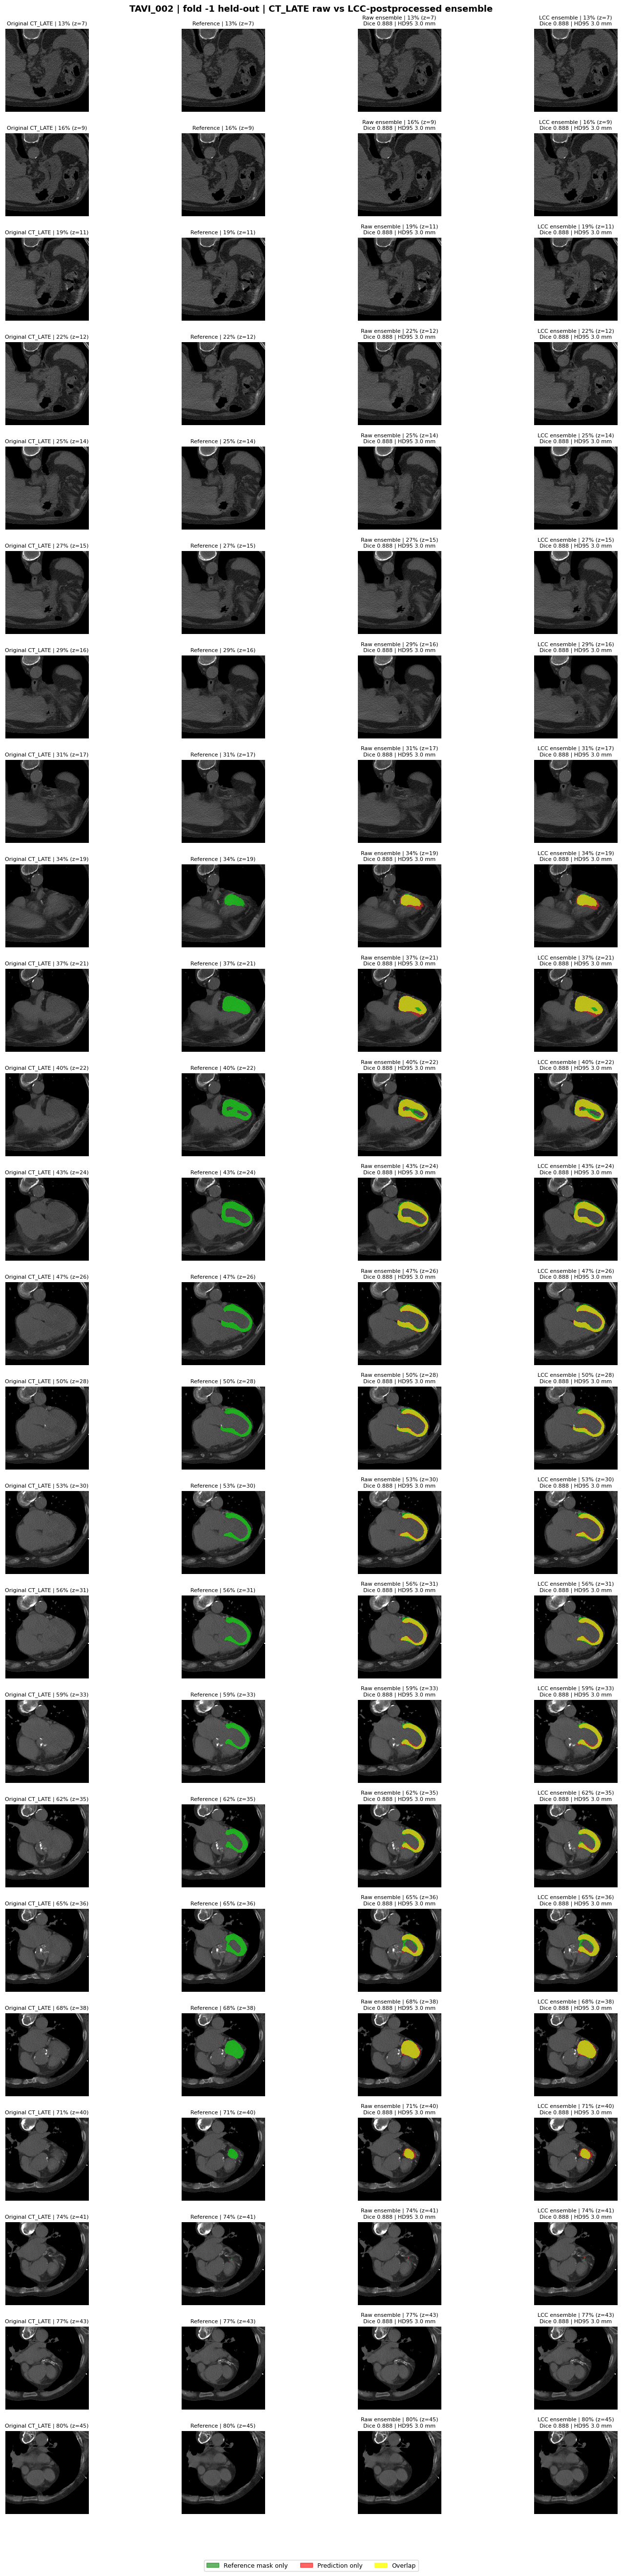

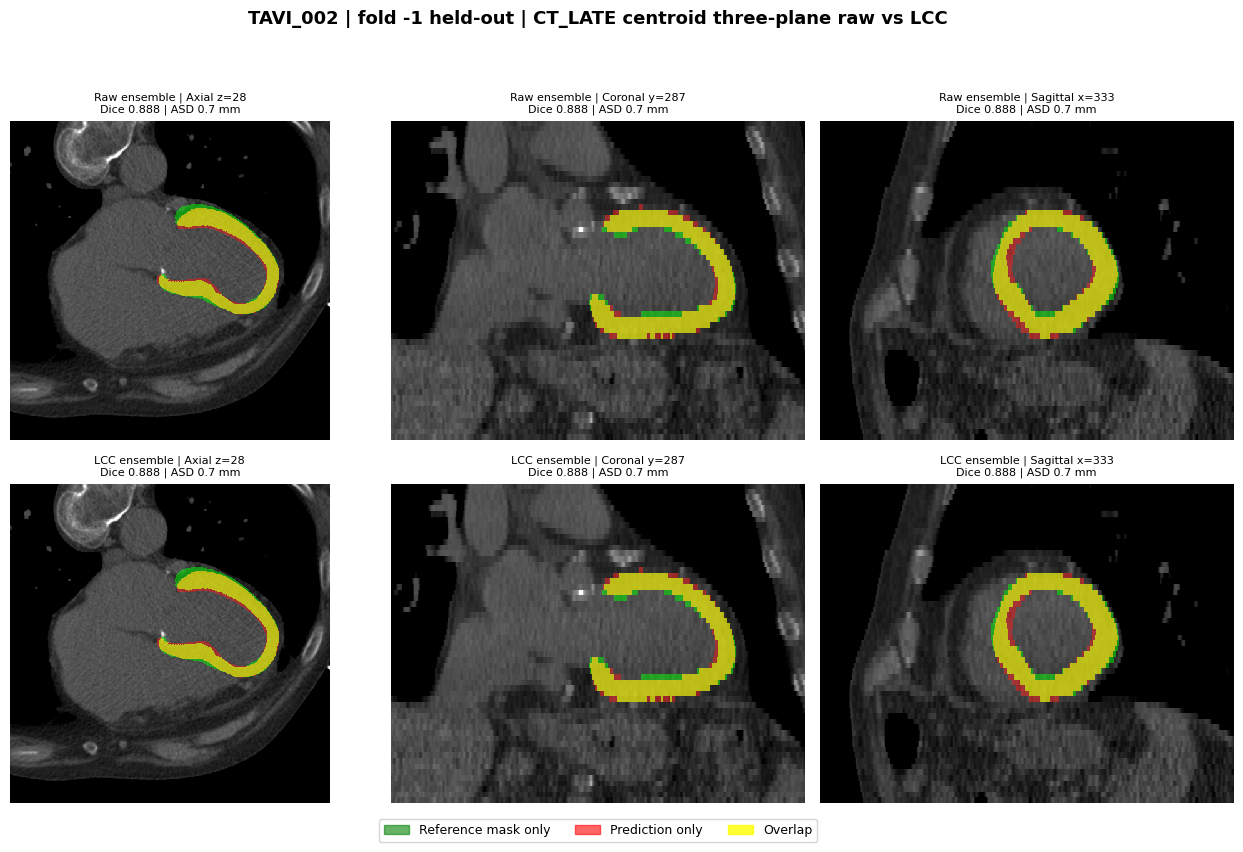

    Saved to /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_002
    raw Dice 0.888 | LCC Dice 0.888 | raw segmentation_ensemble_raw.nii.gz | post segmentation_ensemble_postprocessed.nii.gz

[2/26] Processing TAVI_006 (fold -1 held-out)
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
    fold 0 inference ...
    fold 1 inference ...
    fold 2 inference ...
    fold 3 inference ...
    fold 4 inference ...


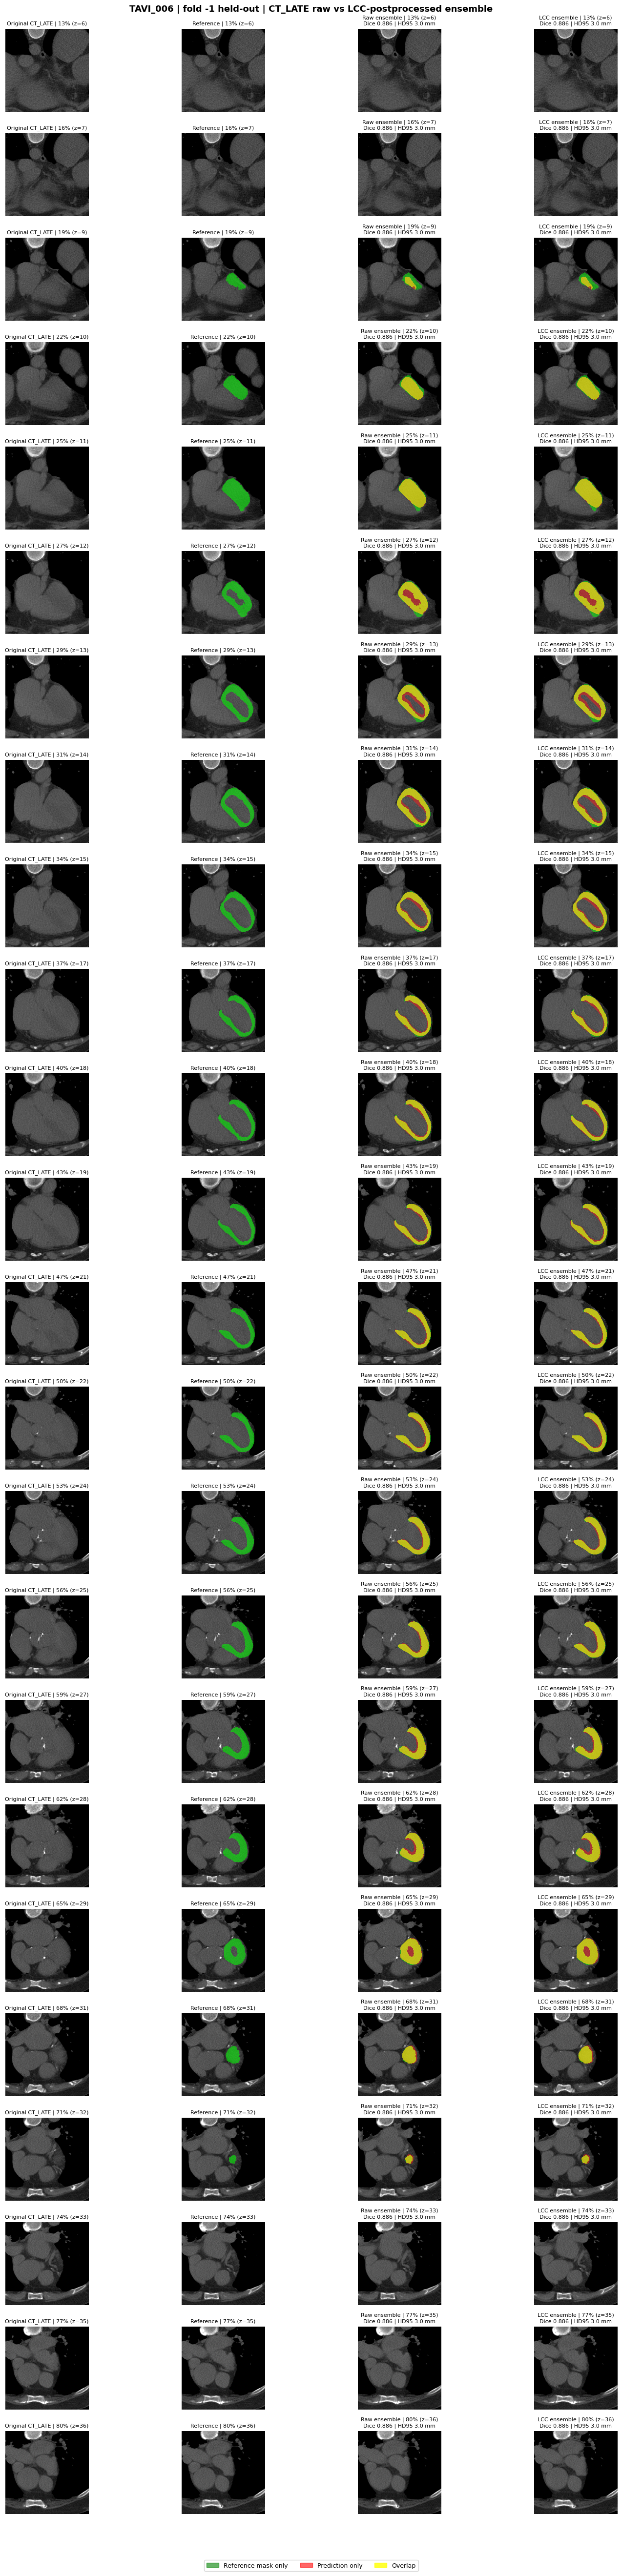

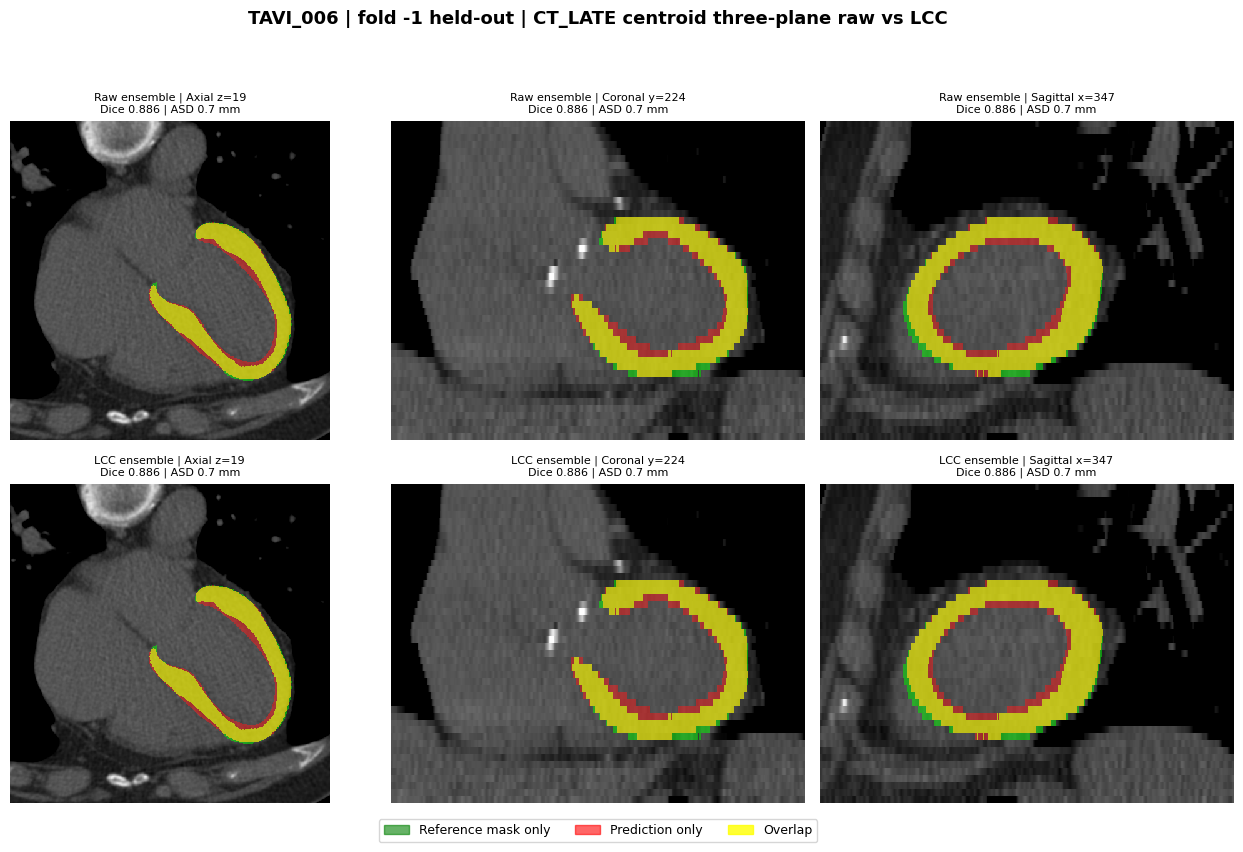

    Saved to /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_006
    raw Dice 0.886 | LCC Dice 0.886 | raw segmentation_ensemble_raw.nii.gz | post segmentation_ensemble_postprocessed.nii.gz

[3/26] Processing TAVI_025 (fold -1 held-out)
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
    fold 0 inference ...
    fold 1 inference ...
    fold 2 inference ...
    fold 3 inference ...
    fold 4 inference ...
    Saved to /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/

In [45]:
# Run full ensemble inference on all selected left-out cases using loaded models.
print(f"Starting full inference on {len(selected_cases)} left-out patients using {len(ensemble_models)} models...")
full_summary_df, full_patient_outputs_df, full_summary_path, full_patient_outputs_path = run_cohort_inference(
    selected_cases,
    LOCAL_OUTPUT_DIR,
    cohort_label="fold -1 held-out",
    summary_filename="leftout_fold_minus1_ensemble_summary.csv",
    display_first_n=DISPLAY_FIRST_N_PATIENTS,
    models=ensemble_models,
)
print(f"Full inference completed. Summary saved to: {full_summary_path}")


## 9. Summary table

In [46]:
df_candidates = [
    globals().get("full_summary_df"),
    globals().get("summary_df"),
    globals().get("summary_df_test"),
    globals().get("qc_summary_df"),
]
summary_df = next((df for df in df_candidates if df is not None), None)

if summary_df is None:
    print("Run the inference cell first, then rerun this summary table cell.")
else:
    metric_cols = [
        "cohort", "patient_id", "model_label", "raw_dice", "postprocessed_dice",
        "raw_hd95_mm", "postprocessed_hd95_mm", "raw_asd_mm", "postprocessed_asd_mm",
        "gt_volume_ml", "raw_pred_volume_ml", "postprocessed_pred_volume_ml",
        "raw_prediction_path", "postprocessed_prediction_path",
    ]
    summary_view = summary_df[metric_cols].sort_values(["patient_id", "model_label"]).copy()
    display(summary_view.style.hide(axis="index").format({
        "raw_dice": "{:.4f}",
        "postprocessed_dice": "{:.4f}",
        "raw_hd95_mm": "{:.2f}",
        "postprocessed_hd95_mm": "{:.2f}",
        "raw_asd_mm": "{:.2f}",
        "postprocessed_asd_mm": "{:.2f}",
        "gt_volume_ml": "{:.2f}",
        "raw_pred_volume_ml": "{:.2f}",
        "postprocessed_pred_volume_ml": "{:.2f}",
    }).set_table_styles([
        {"selector": "th", "props": [("background-color", "#263238"), ("color", "white"), ("font-size", "12px")]},
        {"selector": "td", "props": [("font-size", "12px"), ("padding", "5px 8px")]},
    ]))

    summary_path = globals().get("full_summary_path", globals().get("summary_path", globals().get("summary_path_test", None)))
    patient_outputs_path = globals().get("full_patient_outputs_path", globals().get("patient_outputs_path", globals().get("patient_outputs_path_test", None)))

    print(f"Per-patient folders: {LOCAL_OUTPUT_DIR}")
    if summary_path is not None:
        print(f"Summary CSV: {summary_path}")
    if patient_outputs_path is not None:
        print(f"Patient output index: {patient_outputs_path}")

cohort,patient_id,model_label,raw_dice,postprocessed_dice,raw_hd95_mm,postprocessed_hd95_mm,raw_asd_mm,postprocessed_asd_mm,gt_volume_ml,raw_pred_volume_ml,postprocessed_pred_volume_ml,raw_prediction_path,postprocessed_prediction_path
fold -1 held-out,TAVI_002,5-fold ensemble,0.8876,0.8876,3.00,3.00,0.70,0.70,133.75,136.76,136.76,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_002/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_002/segmentation_ensemble_postprocessed.nii.gz
fold -1 held-out,TAVI_006,5-fold ensemble,0.8856,0.8856,3.00,3.00,0.74,0.74,107.86,118.45,118.45,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_006/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_006/segmentation_ensemble_postprocessed.nii.gz
fold -1 held-out,TAVI_025,5-fold ensemble,0.8705,0.8776,3.03,3.00,1.91,0.74,181.30,183.76,180.79,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_025/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_025/segmentation_ensemble_postprocessed.nii.gz
fold -1 held-out,TAVI_028,5-fold ensemble,0.9085,0.9085,3.00,3.00,0.56,0.56,122.72,126.84,126.84,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_028/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_028/segmentation_ensemble_postprocessed.nii.gz
fold -1 held-out,TAVI_035,5-fold ensemble,0.8657,0.8657,3.04,3.04,1.00,1.00,172.45,180.20,180.20,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_035/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_035/segmentation_ensemble_postprocessed.nii.gz
fold -1 held-out,TAVI_036,5-fold ensemble,0.9145,0.9145,3.00,3.00,0.55,0.55,123.07,120.42,120.42,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_036/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_036/segmentation_ensemble_postprocessed.nii.gz
fold -1 held-out,TAVI_065,5-fold ensemble,0.9009,0.9032,3.00,3.00,0.98,0.68,126.72,121.00,120.37,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_065/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_065/segmentation_ensemble_postprocessed.nii.gz
fold -1 held-out,TAVI_072,5-fold ensemble,0.8827,0.8832,3.06,3.06,0.96,0.79,212.37,199.90,199.70,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_072/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_072/segmentation_ensemble_postprocessed.nii.gz
fold -1 held-out,TAVI_078,5-fold ensemble,0.9010,0.9010,3.00,3.00,0.61,0.61,126.71,131.13,131.13,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_078/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_078/segmentation_ensemble_postprocessed.nii.gz
fold -1 held-out,TAVI_084,5-fold ensemble,0.9247,0.9247,2.57,2.57,0.47,0.47,147.49,151.17,151.17,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/TAVI_084/se

Per-patient folders: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble
Summary CSV: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/leftout_fold_minus1_ensemble_summary.csv
Patient output index: /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/leftout_fold_minus1_ensemble/patient_output_folders.csv


## 10. Optional: check an existing precomputed ensemble output asset

The URI provided for `PRECOMPUTED_ENSEMBLE_OUTPUT_ASSET` is kept in the config cell. If it is a real inference-output asset rather than a fold checkpoint asset, set `DOWNLOAD_PRECOMPUTED_OUTPUT = True` below to download it for inspection without FUSE.

In [47]:
DOWNLOAD_PRECOMPUTED_OUTPUT = False

if DOWNLOAD_PRECOMPUTED_OUTPUT:
    credential = globals().get("credential") or get_credential()
    ml_client = globals().get("ml_client") or get_ml_client(credential)
    precomputed_dir = download_data_asset(
        PRECOMPUTED_ENSEMBLE_OUTPUT_ASSET,
        LOCAL_ASSET_ROOT / "precomputed_ensemble_output",
        ml_client,
        credential,
        OVERWRITE_ASSET_DOWNLOADS,
    )
    print(f"Downloaded precomputed ensemble output to: {precomputed_dir}")
    print("First NIfTI files:")
    for path in list(precomputed_dir.rglob("*.nii.gz"))[:20]:
        print(path)
else:
    print("Skipped precomputed output download.")

Skipped precomputed output download.


## 11. QC 0/1 low-quality mask review

These cases have `QC RESULT` equal to `0` or `1` in `data/qc_results.csv`. The exported files let you inspect whether the model prediction is more plausible than the available low-quality `registration_mask.nii.gz` reference.

Selected 48 QC 0/1 low-quality patients:
['TAVI_003', 'TAVI_008', 'TAVI_011', 'TAVI_030', 'TAVI_039', 'TAVI_040', 'TAVI_047', 'TAVI_050', 'TAVI_071', 'TAVI_073', 'TAVI_074', 'TAVI_075', 'TAVI_082', 'TAVI_088', 'TAVI_095', 'TAVI_098', 'TAVI_101', 'TAVI_104', 'TAVI_105', 'TAVI_110', 'TAVI_119', 'TAVI_122', 'TAVI_128', 'TAVI_130', 'TAVI_141', 'TAVI_148', 'TAVI_153', 'TAVI_180', 'TAVI_201', 'TAVI_203'] ...

[1/48] Processing TAVI_003 (QC 0/1 low-quality reference)
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
    fold 0 inference ...


Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1769685250281/work/torch/csrc/autograd/python_variable_indexing.cpp:353.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runnerx/miniforge3/conda-bld/libtorch_1769685250281/work/torch/csrc/autograd/python_variable_indexing.cpp:353.)


    fold 1 inference ...
    fold 2 inference ...
    fold 3 inference ...
    fold 4 inference ...


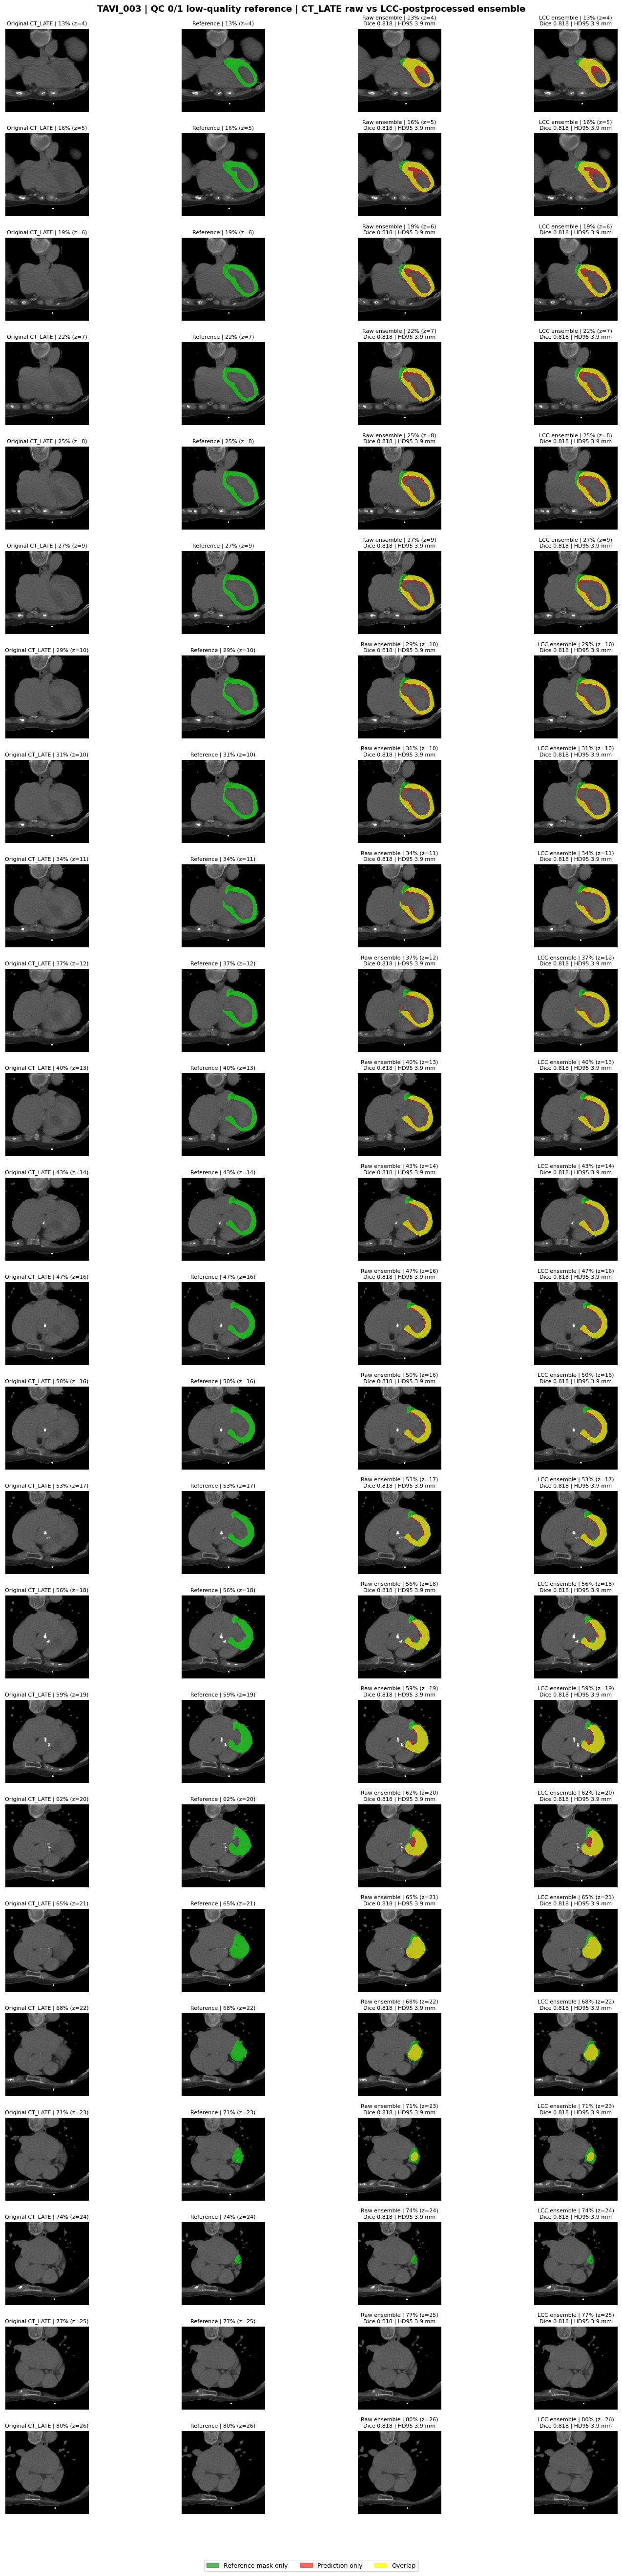

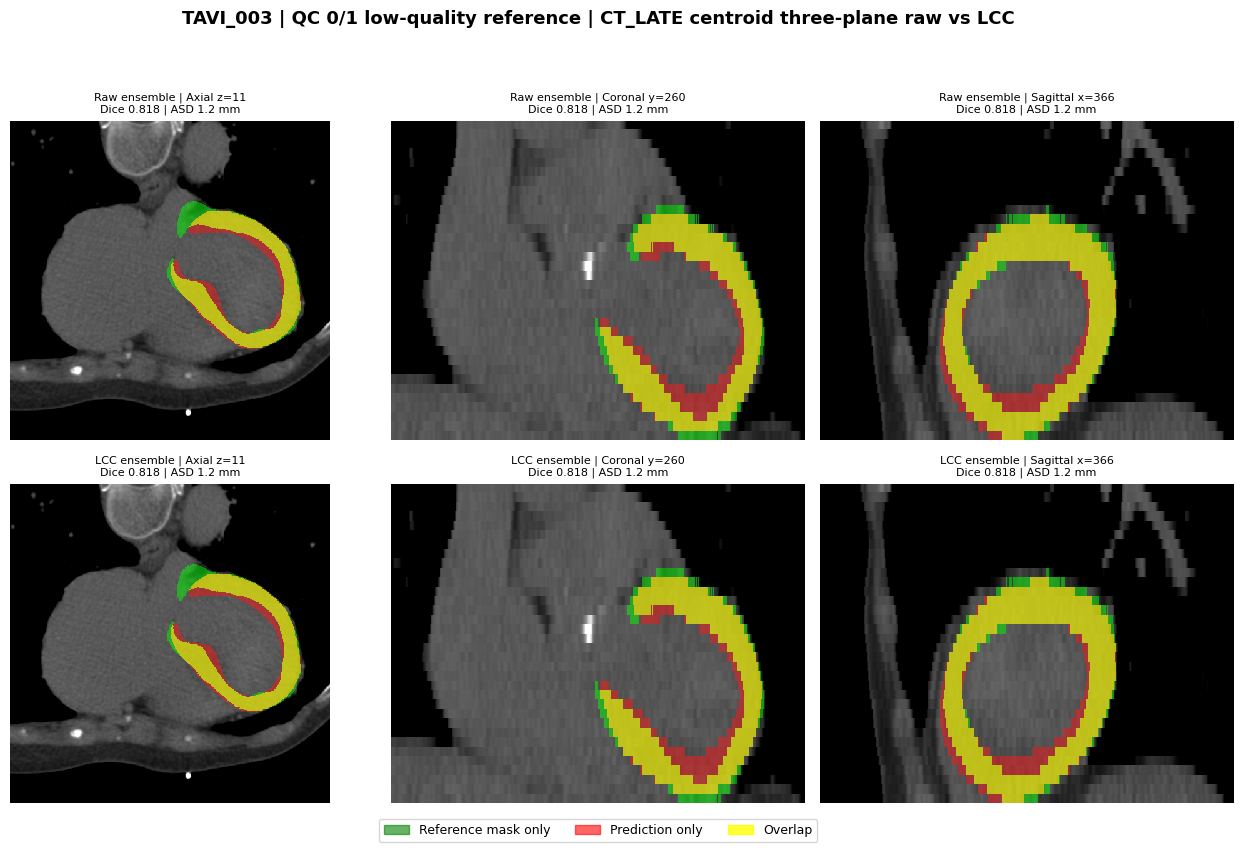

    Saved to /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_003
    raw Dice 0.818 | LCC Dice 0.818 | raw segmentation_ensemble_raw.nii.gz | post segmentation_ensemble_postprocessed.nii.gz

[2/48] Processing TAVI_008 (QC 0/1 low-quality reference)
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
    fold 0 inference ...
    fold 1 inference ...
    fold 2 inference ...
    fold 3 inference ...
    fold 4 inference ...


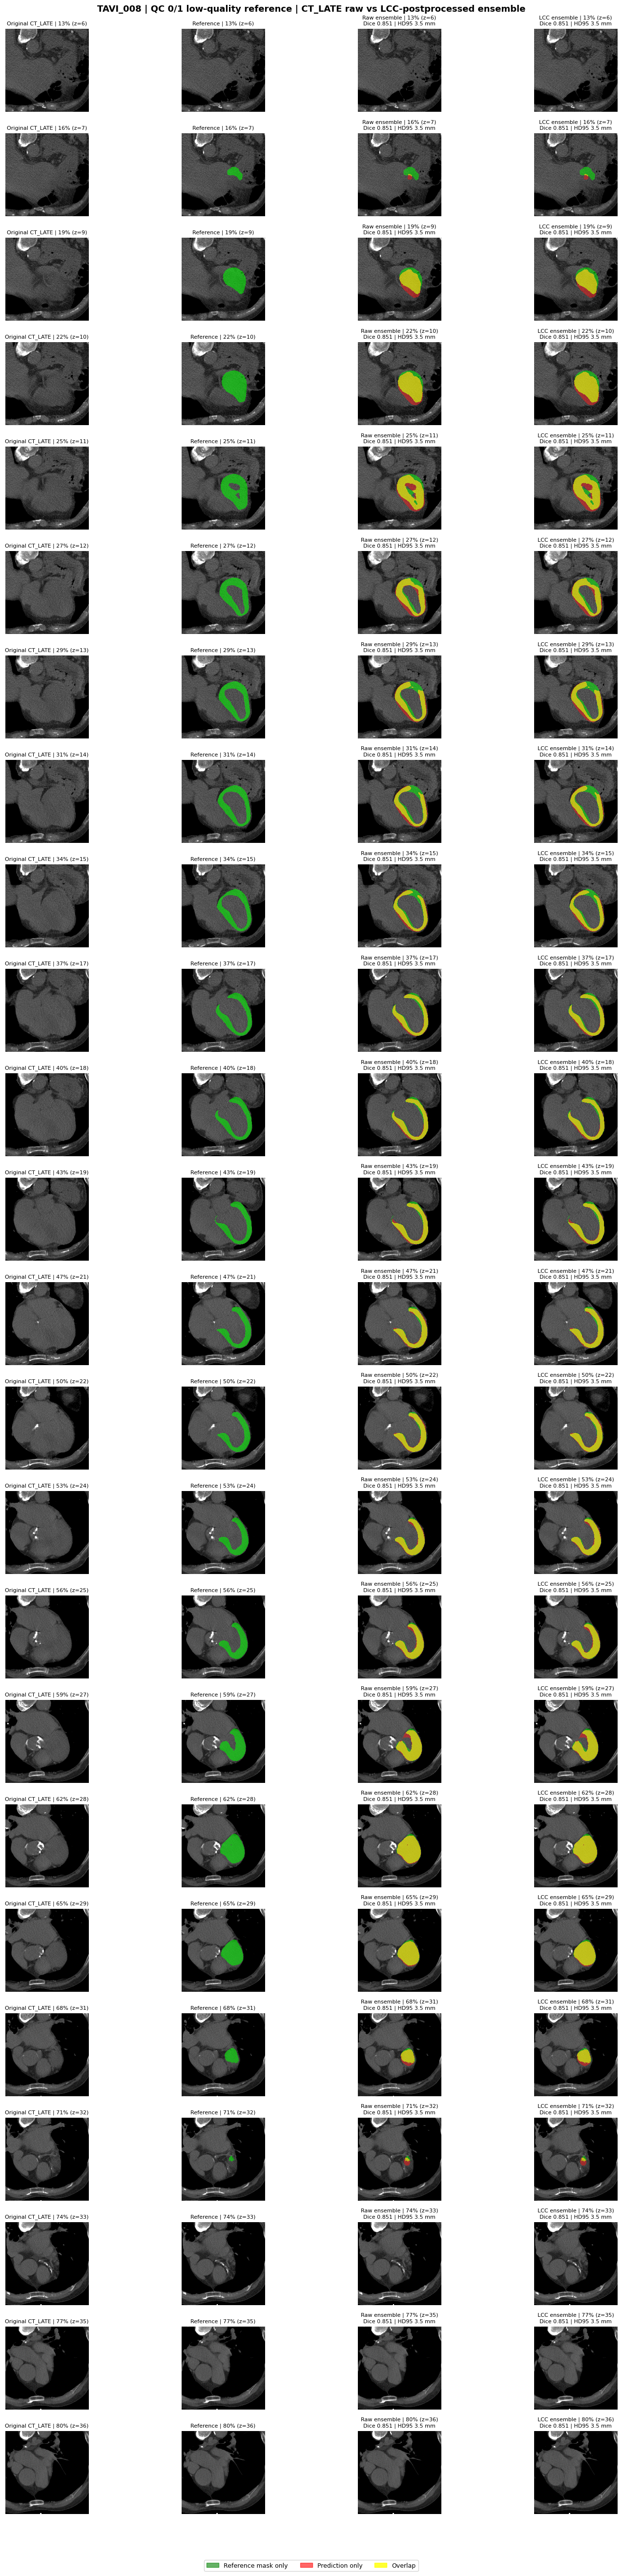

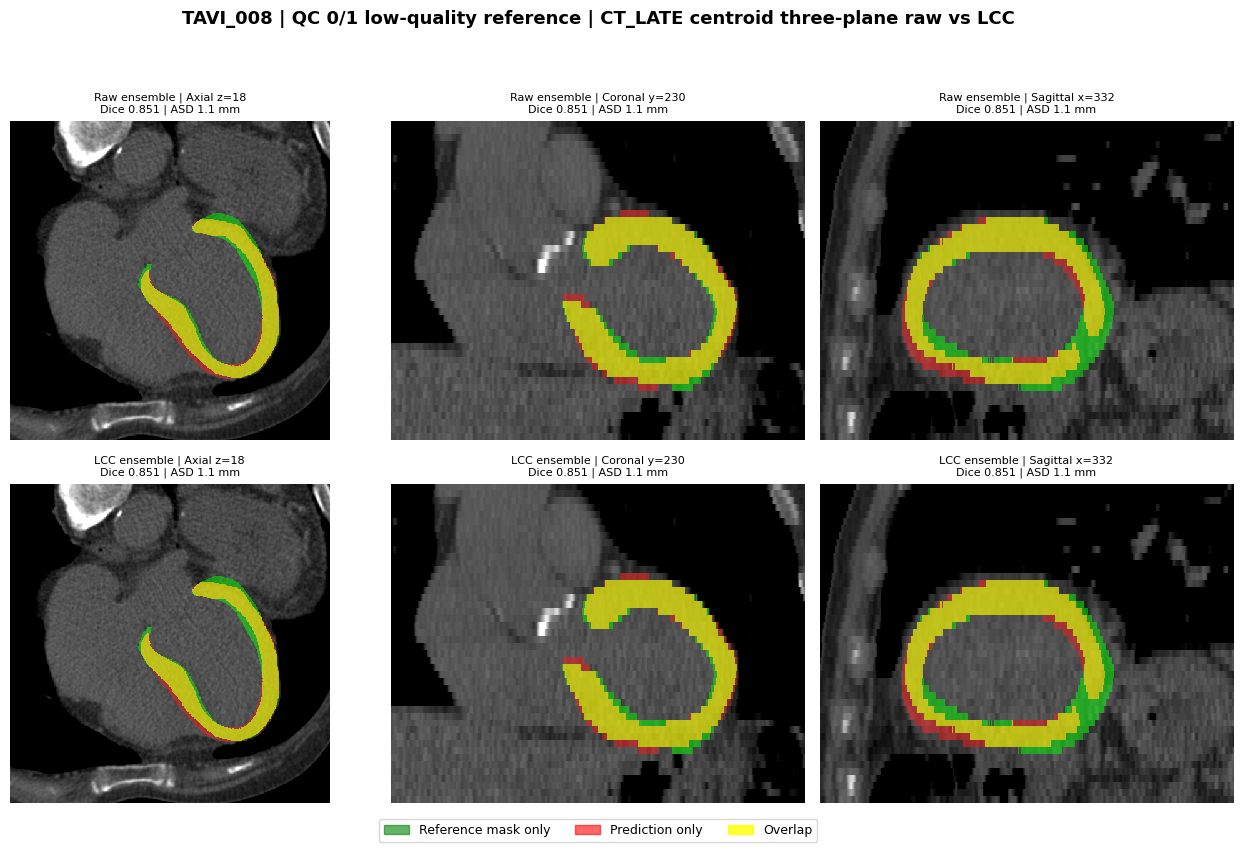

    Saved to /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_008
    raw Dice 0.851 | LCC Dice 0.851 | raw segmentation_ensemble_raw.nii.gz | post segmentation_ensemble_postprocessed.nii.gz

[3/48] Processing TAVI_011 (QC 0/1 low-quality reference)
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
    fold 0 inference ...
    fold 1 inference ...
    fold 2 inference ...
    fold 3 inference ...
    fold 4 inference ...
    Saved to /Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/o

In [48]:
DATA_ROOT, low_quality_cases = select_low_quality_qc_cases(
    DATA_ROOT,
    case_names=LOW_QUALITY_CASE_NAMES,
    max_patients=LOW_QUALITY_MAX_PATIENTS,
)
print(f"Selected {len(low_quality_cases)} QC 0/1 low-quality patients:")
print([case["name"] for case in low_quality_cases[:30]], "..." if len(low_quality_cases) > 30 else "")

qc_summary_df, qc_patient_outputs_df, qc_summary_path, qc_patient_outputs_path = run_cohort_inference(
    low_quality_cases,
    LOW_QUALITY_OUTPUT_DIR,
    cohort_label="QC 0/1 low-quality reference",
    summary_filename="qc_0_1_ensemble_review_summary.csv",
    models=ensemble_models,
)

print(f"QC 0/1 per-patient folders: {LOW_QUALITY_OUTPUT_DIR}")
print(f"QC 0/1 summary CSV: {qc_summary_path}")
print(f"QC 0/1 patient output index: {qc_patient_outputs_path}")


In [49]:
if "qc_summary_df" not in globals():
    raise RuntimeError("Run the QC 0/1 inference cell before displaying this table.")

qc_metric_cols = [
    "cohort", "patient_id", "raw_dice", "postprocessed_dice",
    "raw_pred_volume_ml", "postprocessed_pred_volume_ml", "gt_volume_ml",
    "raw_prediction_path", "postprocessed_prediction_path",
]
qc_summary_view = qc_summary_df[qc_metric_cols].sort_values("patient_id").copy()
display(qc_summary_view.style.hide(axis="index").format({
    "raw_dice": "{:.4f}",
    "postprocessed_dice": "{:.4f}",
    "raw_pred_volume_ml": "{:.2f}",
    "postprocessed_pred_volume_ml": "{:.2f}",
    "gt_volume_ml": "{:.2f}",
}).set_table_styles([
    {"selector": "th", "props": [("background-color", "#4e342e"), ("color", "white"), ("font-size", "12px")]},
    {"selector": "td", "props": [("font-size", "12px"), ("padding", "5px 8px")]},
]))

cohort,patient_id,raw_dice,postprocessed_dice,raw_pred_volume_ml,postprocessed_pred_volume_ml,gt_volume_ml,raw_prediction_path,postprocessed_prediction_path
QC 0/1 low-quality reference,TAVI_003,0.8181,0.8181,122.35,122.35,114.57,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_003/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_003/segmentation_ensemble_postprocessed.nii.gz
QC 0/1 low-quality reference,TAVI_008,0.8513,0.8513,158.94,158.94,162.18,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_008/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_008/segmentation_ensemble_postprocessed.nii.gz
QC 0/1 low-quality reference,TAVI_011,0.8163,0.8163,85.63,85.63,87.48,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_011/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_011/segmentation_ensemble_postprocessed.nii.gz
QC 0/1 low-quality reference,TAVI_030,0.8152,0.8152,114.59,114.59,119.39,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_030/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_030/segmentation_ensemble_postprocessed.nii.gz
QC 0/1 low-quality reference,TAVI_039,0.7864,0.7864,139.68,139.68,133.13,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_039/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_039/segmentation_ensemble_postprocessed.nii.gz
QC 0/1 low-quality reference,TAVI_040,0.8116,0.8116,92.48,92.48,106.51,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_040/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_040/segmentation_ensemble_postprocessed.nii.gz
QC 0/1 low-quality reference,TAVI_047,0.8753,0.8753,151.51,151.51,137.98,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_047/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_047/segmentation_ensemble_postprocessed.nii.gz
QC 0/1 low-quality reference,TAVI_050,0.9180,0.9180,113.21,113.21,112.17,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_050/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_050/segmentation_ensemble_postprocessed.nii.gz
QC 0/1 low-quality reference,TAVI_071,0.8677,0.8677,191.07,191.07,210.33,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_071/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_071/segmentation_ensemble_postprocessed.nii.gz
QC 0/1 low-quality reference,TAVI_073,0.7462,0.7462,118.27,118.27,136.34,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_073/segmentation_ensemble_raw.nii.gz,/Users/ricca/Desktop/Health_Informatics_Internship_2026/notebooks/output/QC_1_0_ensemble/TAVI_073/segmentation_ensemble_postprocessed.nii.gz


In [50]:
RUN_SMOKE_TEST = False

if RUN_SMOKE_TEST:
    test_cases = selected_cases[:1]
    if not globals().get("ensemble_models"):
        raise RuntimeError("Smoke test requires loaded ensemble models. Run the model-loading cell first.")

    print(f"Running smoke inference for {len(test_cases)} patient(s): {[c['name'] for c in test_cases]}")
    summary_df_test, patient_outputs_df_test, summary_path_test, patient_outputs_path_test = run_cohort_inference(
        test_cases,
        LOCAL_OUTPUT_DIR,
        cohort_label="fold -1 held-out (smoke)",
        summary_filename="smoke_leftout_summary.csv",
        display_first_n=1,
        models=ensemble_models,
    )
    print(f"Smoke run saved summary to: {summary_path_test}")
else:
    print("Skipped smoke test. Set RUN_SMOKE_TEST = True to run a one-patient check.")


Skipped smoke test. Set RUN_SMOKE_TEST = True to run a one-patient check.
